# Did the 2022–2024 rate shock render IRRBB compliance and NII preservation incompatible for retail banks?

**Nino Petiard — Master MBFA, Paris 1 Panthéon Sorbonne — 2025-2026**

---

## Project overview

This notebook implements the complete quantitative simulation underpinning the thesis. It follows the operational logic of an ALM team and is structured in five parts:

1. **Foundations**: imports, EUR OIS yield curve (March 2024), construction of the 10 Bn€ stylised balance sheet, client behaviour modelling
2. **Exposure diagnostic**: rate gap, NII under the six EBA scenarios, EVE and prudential alerts
3. **Hedging strategy**: bucket-by-bucket calibration, formal optimisation of hedge ratios (SLSQP), EVE impact, NII/EVE efficient frontier, carry cost
4. **Supplementary analyses**: NII under constant balance sheet assumption, sensitivity to behavioural assumptions
5. **Stochastic extensions**: Hull-White Monte Carlo (1,000 trajectories), dynamic client behaviours (500 trajectories)

**Reference balance sheet**: 10 Bn€ | **Calibration date**: March 2024 | **Curve**: EUR OIS (Bloomberg)

---


---
## Part 1 — Foundations
---


### 1.1 Imports and configuration


In [28]:
# =============================================
# CELL 1 — IMPORTS AND CONFIGURATION
# =============================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import CubicSpline
import warnings
import os

warnings.filterwarnings('ignore')

DOSSIER_FIGURES = r'C:\\Users\\npeti\\Documents\\Projet 2 - ALM\\figures'
os.makedirs(DOSSIER_FIGURES, exist_ok=True)

# Global colour palette — used in all cells
C_NEG    = '#C0392B'
C_POS    = '#27AE60'
C_NEUTRE = '#2C3E50'
C_BAISSE = '#2980B9'
C_ALERTE = '#E74C3C'
C_FOND   = '#F8F9FA'
C_GRILLE = '#DEE2E6'

def style_ax(ax, title):
    ax.set_facecolor(C_FOND)
    ax.set_title(title, fontsize=10, fontweight='bold', color=C_NEUTRE, pad=8)
    ax.grid(alpha=0.5, color=C_GRILLE, linewidth=0.7, axis='y')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color(C_GRILLE)
    ax.spines['bottom'].set_color(C_GRILLE)
    ax.tick_params(colors=C_NEUTRE, labelsize=8)

print("Libraries imported ✓")
print(f"Figures folder: {DOSSIER_FIGURES} ✓")


Libraries imported ✓
Figures folder: C:\\Users\\npeti\\Documents\\Projet 2 - ALM\\figures ✓


### 1.2 EUR OIS zero-coupon yield curve — March 2024

The simulation uses the EUR OIS swap curve of March 2024, interpolated by cubic spline over eleven observed points (source: Bloomberg). Its defining feature is its inversion: the 3-month rate stands at 3.85% versus 2.78% at ten years, an inversion of 107 bp. This configuration is the central macro-financial parameter of the thesis: it makes the carry on pay-fixed IRS swaps positive, which is the cornerstone of NII/EVE compatibility.


EUR ZERO-COUPON YIELD CURVE — March 2024
  0.25 yr(s) 3.850%
  0.5 yr(s)  3.750%
  1 yr(s)    3.600%
  2 yr(s)    3.200%
  3 yr(s)    3.000%
  5 yr(s)    2.850%
  7 yr(s)    2.800%
  10 yr(s)   2.780%
  15 yr(s)   2.750%
  20 yr(s)   2.720%
  30 yr(s)   2.680%

Curve inversion: 1 bp
(3M rate = 3.85% > 10Y rate = 2.78%)


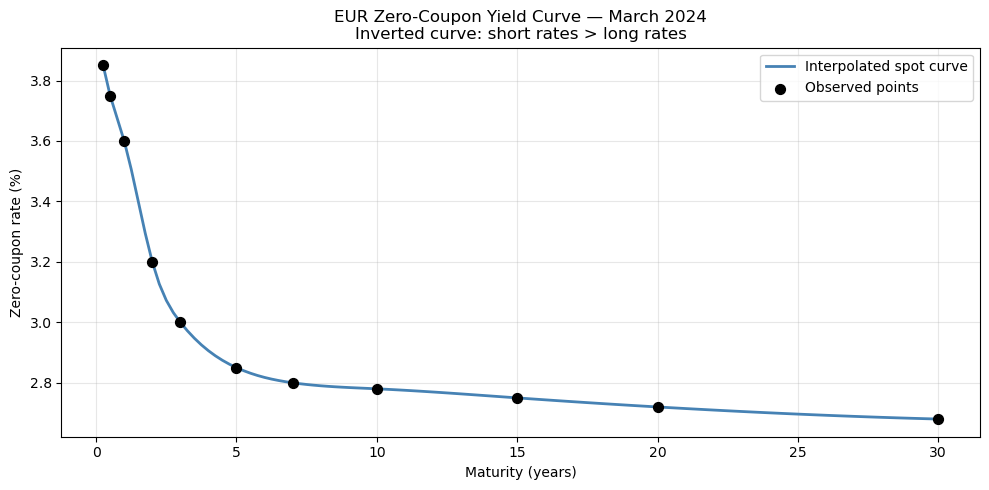

Figure 01_courbe_taux.png saved ✓


In [29]:
# =============================================
# CELL 2 — EUR OIS ZERO-COUPON YIELD CURVE (MARCH 2024)
# =============================================
# Source: Bloomberg EUR OIS curve, March 2024
# Risk-free reference curve (€STR) — EBA IRRBB standard
# Cubic spline interpolation for derivative continuity

maturites_obs = np.array([0.25, 0.5, 1, 2, 3, 5, 7, 10, 15, 20, 30])
taux_obs      = np.array([3.85, 3.75, 3.60, 3.20, 3.00,
                           2.85, 2.80, 2.78, 2.75, 2.72, 2.68])

courbe_taux = CubicSpline(maturites_obs, taux_obs / 100)
maturites   = np.arange(0.25, 30.25, 0.25)
taux_spot   = courbe_taux(maturites)

print("EUR ZERO-COUPON YIELD CURVE — March 2024")
print("=" * 45)
for m in [0.25, 0.5, 1, 2, 3, 5, 7, 10, 15, 20, 30]:
    print(f"  {str(m)+' yr(s)':<10} {courbe_taux(m)*100:.3f}%")

print()
print(f"Curve inversion: {(courbe_taux(0.25) - courbe_taux(10))*100:.0f} bp")
print(f"(3M rate = {courbe_taux(0.25)*100:.2f}% > 10Y rate = {courbe_taux(10)*100:.2f}%)")

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(maturites, taux_spot * 100, color='steelblue', linewidth=2,
        label='Interpolated spot curve')
ax.scatter(maturites_obs, taux_obs, color='black', s=50, zorder=5,
           label='Observed points')
ax.set_title("EUR Zero-Coupon Yield Curve — March 2024\nInverted curve: short rates > long rates")
ax.set_xlabel("Maturity (years)")
ax.set_ylabel("Zero-coupon rate (%)")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(DOSSIER_FIGURES, '01_courbe_taux.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Figure 01_courbe_taux.png saved ✓")


### 1.3 Balance sheet construction

Stylised balance sheet of a mid-sized French retail bank, calibrated on public data (Banque de France, Observatoire Crédit Logement, ACPR). Total assets: 10 Bn€. Share of fixed-rate assets: 73%. Maturity gap: 7.1 years. Structural position: *liability-sensitive*.


In [30]:
# =============================================
# CELL 3 — BALANCE SHEET CONSTRUCTION
# =============================================
# Stylised balance sheet of a mid-sized French retail bank
# Total assets: 10 Bn€ | Calibration: March 2024
# Sources: Banque de France, ACPR, Observatoire Crédit Logement

actif = pd.DataFrame({
    'Item': [
        'Fixed-rate mortgage loans',
        'Variable-rate mortgage loans',
        'Consumer loans',
        'Fixed-rate corporate loans',
        'Variable-rate corporate loans',
        'Sovereign bond portfolio',
        'Treasury and liquid assets'
    ],
    'Amount_M':         [3500, 1000, 800, 1500, 700, 1500, 1000],
    'Contractual_rate':  [1.80, 4.10, 5.50, 2.50, 4.35, 1.20, 3.90],
    'Maturity_yrs':      [18.0, 15.0,  3.0,  5.0,  3.0,  6.0, 0.25],
    'Rate_type':         ['Fixed','Variable','Fixed','Fixed','Variable','Fixed','Variable'],
    'Amortisation':     ['Linear','Linear','Linear','Linear',
                          'Linear','Bullet','Bullet'],
})

passif = pd.DataFrame({
    'Item': [
        'Demand deposits',
        'Livret A and regulated savings',
        'Term deposits',
        'Senior bonds issued',
        'ECB refinancing (TLTRO)',
        'Tier 1 equity'
    ],
    'Amount_M':         [3500, 2000, 1500, 1500,  600,  900],
    'Contractual_rate':  [0.10, 3.00, 3.50, 1.80, 0.75,  0.0],
    'Maturity_yrs':      [3.0,  4.0,  1.5,  4.5,  0.5,   0.0],
    'Rate_type':         ['Variable','Administered','Fixed','Fixed','Fixed','N/A'],
    'Amortisation':     ['Linear','Linear','Bullet','Bullet','Bullet','N/A'],
})

total_actif   = actif['Amount_M'].sum()
total_passif  = passif['Amount_M'].sum()
fonds_propres_t1 = 900

taux_actif_moyen  = (actif['Amount_M'] * actif['Contractual_rate']).sum() / total_actif
taux_passif_moyen = (passif[passif['Rate_type'] != 'N/A']['Amount_M'] *
                     passif[passif['Rate_type'] != 'N/A']['Contractual_rate']).sum() / total_passif
marge_nette = taux_actif_moyen - taux_passif_moyen

mat_actif_moy  = (actif['Amount_M'] * actif['Maturity_yrs']).sum() / total_actif
mat_passif_moy = (passif[passif['Rate_type'] != 'N/A']['Amount_M'] *
                  passif[passif['Rate_type'] != 'N/A']['Maturity_yrs']).sum() / total_passif

montant_fixe_actif = actif[actif['Rate_type'] == 'Fixed']['Amount_M'].sum()

print("BALANCE SHEET STRUCTURAL DIAGNOSTIC")
print("=" * 45)
print(f"  Total assets        : {total_actif:>8} M€")
print(f"  Tier 1 equity       : {fonds_propres_t1:>8} M€")
print(f"  Avg asset rate      : {taux_actif_moyen:>8.3f}%")
print(f"  Avg liability rate  : {taux_passif_moyen:>8.3f}%")
print(f"  Net gross margin    : {marge_nette:>8.3f}%")
print(f"  Asset maturity      : {mat_actif_moy:>8.1f} yrs")
print(f"  Liability maturity  : {mat_passif_moy:>8.1f} yrs")
print(f"  Maturity gap        : {mat_actif_moy - mat_passif_moy:>8.1f} yrs")
print(f"  Fixed-rate asset %  : {montant_fixe_actif/total_actif*100:>8.1f}%")
print(f"  Position            : {'liability-sensitive':>12}")
print(f"  Balance sheet check : {'✓' if total_actif == total_passif else '✗'}")


BALANCE SHEET STRUCTURAL DIAGNOSTIC
  Total assets        :    10000 M€
  Tier 1 equity       :      900 M€
  Avg asset rate      :    2.729%
  Avg liability rate  :    1.475%
  Net gross margin    :    1.254%
  Asset maturity      :      9.9 yrs
  Liability maturity  :      2.8 yrs
  Maturity gap        :      7.1 yrs
  Fixed-rate asset %  :     73.0%
  Position            : liability-sensitive
  Balance sheet check : ✓


### 1.4 Client behaviour modelling

Two behaviours deviate from contractual terms: the economic duration of demand deposits (central assumption: 3 years, 70%/30% stable/volatile segmentation) and the prepayment rate (floor of 5% in March 2024 due to the maximal lock-in effect: contractual rate 1.80% versus market rate 4.20%).


In [31]:
# =============================================
# CELL 4 — CLIENT BEHAVIOUR MODELLING
# =============================================
# Two behaviours deviate from contractual terms:
# 1. Economic duration of demand deposits
# 2. Prepayment rate

# ─── PREPAYMENT ───────────────────────────────────────────────
# March 2024: market rate 4.20% >> average contractual rate 1.80%
# → maximal lock-in effect → prepayment at structural floor 5%
# Consistent with 5-7% observed on French stock in 2023
# (Banque de France, Stat Info 2023)

prepay_dict = {
    'Fixed-rate mortgage loans':          0.05,
    'Variable-rate mortgage loans':       0.05,
    'Consumer loans':                     0.08,
    'Fixed-rate corporate loans':         0.05,
    'Variable-rate corporate loans':      0.05,
    'Sovereign bond portfolio':           0.00,
    'Treasury and liquid assets':         0.00,
}

# ─── DEMAND DEPOSITS ──────────────────────────────────────────
# Legally repayable at any time, but longer economic duration
# due to switching costs (Sharpe 1990).
# Retained duration: 3 years (central assumption, French market practice)
# Segmentation: 70% stable (core, 4 yrs) / 30% volatile (1 yr)
# → average duration = 0.70×4 + 0.30×1 = 3.1 yrs ≈ 3 yrs
# EBA/GL/2022/14 regulatory cap: 5 years

duree_dav_centrale = 3.0  # ans

print("RETAINED BEHAVIOURAL ASSUMPTIONS")
print("=" * 50)
print(f"  Demand deposit duration (central): {duree_dav_centrale} yrs")
print(f"  Core/non-core segmentation      : 70% / 30%")
print(f"  Prepayment fixed mortgages      : {prepay_dict['Fixed-rate mortgage loans']:.0%}")
print(f"  (maximal lock-in — market rate {courbe_taux(0.25)*100:.2f}% >> contractual 1.80%)")
print()
print("  NOTE: These assumptions are estimation parameters")
print("  subject to model risk review. The sensitivity analysis (cell 10)")
print("  and Extension C test their robustness.")


RETAINED BEHAVIOURAL ASSUMPTIONS
  Demand deposit duration (central): 3.0 yrs
  Core/non-core segmentation      : 70% / 30%
  Prepayment fixed mortgages      : 5%
  (maximal lock-in — market rate 3.85% >> contractual 1.80%)

  NOTE: These assumptions are estimation parameters
  subject to model risk review. The sensitivity analysis (cell 10)
  and Extension C test their robustness.


---
## Part 2 — Interest rate risk exposure diagnostic
---


### 2.1 Rate gap — Radiograph of transformation

The gap measures, for each EBA maturity bucket, the difference between outstanding assets and liabilities liable to reprice. Massively *liability-sensitive* position on short buckets (cumulative gap of −2,477 M€ up to 2 years) and *asset-sensitive* on long buckets (concentrated in mortgage loans and the sovereign bond portfolio).


RATE GAP BY MATURITY BUCKET
Bucket            Actif     Passif        Gap   Gap cumulé Position
---------------------------------------------------------------------------
0-3M             2969M€     4258M€    -1290M€      -1290M€  Liability-sensitive
3-6M              266M€      758M€     -492M€      -1782M€  Liability-sensitive
6M-1Y             526M€      917M€     -391M€      -2173M€  Liability-sensitive
1Y-2Y            1029M€     1333M€     -304M€      -2477M€  Liability-sensitive
2Y-3Y             983M€      833M€      150M€      -2327M€  Asset-sensitive
3Y-5Y            1341M€     1000M€      341M€      -1987M€  Asset-sensitive
5Y-7Y            2142M€        0M€     2142M€        155M€  Asset-sensitive
7Y-10Y            904M€        0M€      904M€       1059M€  Asset-sensitive
10Y-15Y          1361M€        0M€     1361M€       2420M€  Asset-sensitive
15Y-20Y           671M€        0M€      671M€       3091M€  Asset-sensitive
20Y-30Y             0M€        0M€        0M€       

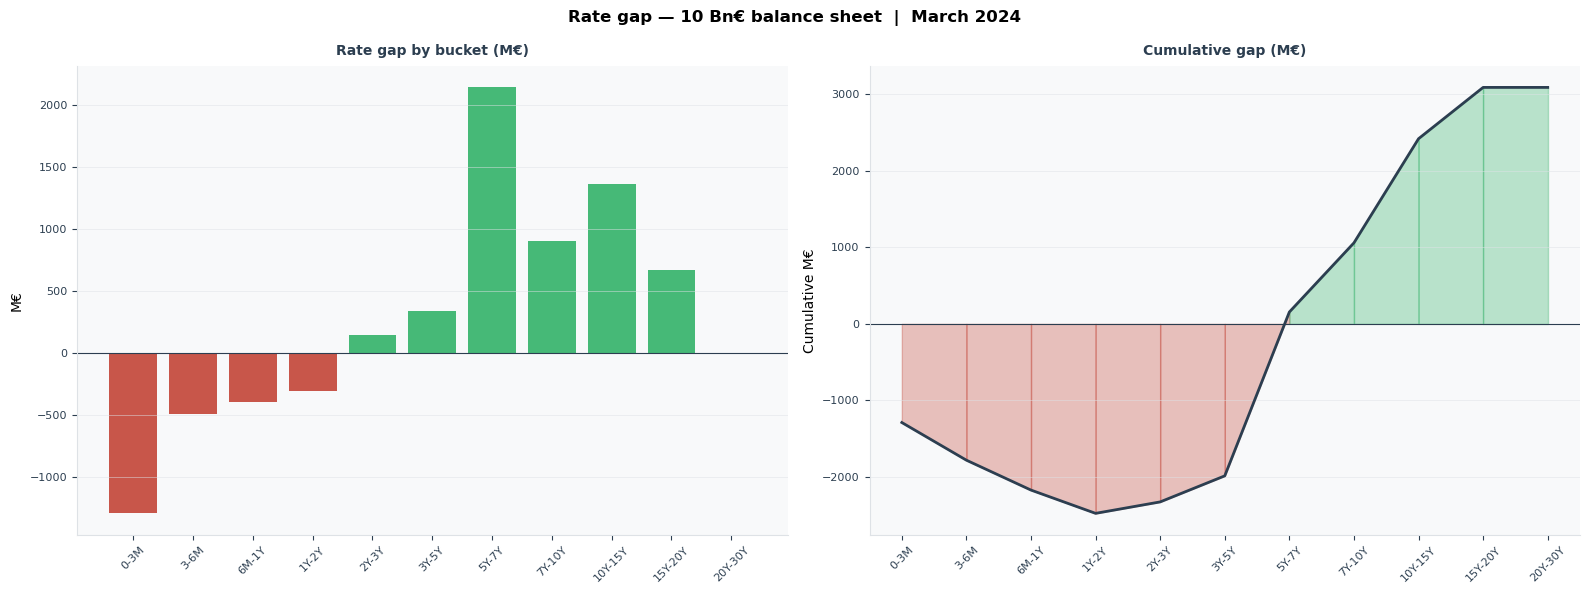

Figure 03_gap_taux.png saved ✓


In [32]:
# =============================================
# CELL 7 — RATE GAP
# =============================================
# EBA Buckets | Gap = Repriceable assets - Repriceable liabilities

buckets = [
    (0,    0.25,  '0-3M'),
    (0.25, 0.5,   '3-6M'),
    (0.5,  1.0,   '6M-1Y'),
    (1.0,  2.0,   '1Y-2Y'),
    (2.0,  3.0,   '2Y-3Y'),
    (3.0,  5.0,   '3Y-5Y'),
    (5.0,  7.0,   '5Y-7Y'),
    (7.0,  10.0,  '7Y-10Y'),
    (10.0, 15.0,  '10Y-15Y'),
    (15.0, 20.0,  '15Y-20Y'),
    (20.0, 30.0,  '20Y-30Y'),
]

def montant_repriceable(montant, taux_contrat, maturite,
                         type_taux, amortissement,
                         t_debut, t_fin, prepay_rate=0.05):
    """
    Amount repricing within bucket [t_start, t_end].

    Variable rate → full notional reprices immediately (bucket 0)
    Fixed bullet → single repayment at maturity
    Fixed linear → capital flows distributed over life
    """
    if type_taux == 'Variable':  # kept as internal logic key
        return montant if t_debut == 0 else 0.0

    if amortissement == 'Bullet':
        return montant if (t_debut <= maturite < t_fin) else 0.0

    if amortissement == 'Linear':
        if t_debut >= maturite:
            return 0.0
        # Encours au début du bucket
        encours_debut = max(0, montant * (1 - t_debut / maturite))
        # Flux de capital dans le bucket
        n_trim        = (min(t_fin, maturite) - t_debut) / 0.25
        amort_trim    = montant / (maturite / 0.25)
        flux_prepay   = encours_debut * prepay_rate * (min(t_fin, maturite) - t_debut)
        return max(0, amort_trim * n_trim + flux_prepay)

    return 0.0

gap_data = []
for t_debut, t_fin, label in buckets:
    actif_reprice = sum(
        montant_repriceable(row['Amount_M'], row['Contractual_rate'],
                            row['Maturity_yrs'], row['Rate_type'],
                            row['Amortisation'], t_debut, t_fin,
                            prepay_dict.get(row['Item'], 0.05))
        for _, row in actif.iterrows())

    passif_reprice = sum(
        montant_repriceable(row['Amount_M'], row['Contractual_rate'],
                            row['Maturity_yrs'], row['Rate_type'],
                            'Linear', t_debut, t_fin, 0.0)
        for _, row in passif.iterrows()
        if row['Rate_type'] != 'N/A')

    gap_data.append({'Bucket': label, 'Actif_reprice': actif_reprice,
                     'Passif_reprice': passif_reprice, 'Gap': actif_reprice - passif_reprice})

df_gap = pd.DataFrame(gap_data)
df_gap['Gap_cumule'] = df_gap['Gap'].cumsum()

print("RATE GAP BY MATURITY BUCKET")
print("=" * 75)
print(f"{'Bucket':<12} {'Actif':>10} {'Passif':>10} {'Gap':>10} {'Gap cumulé':>12} {'Position'}")
print("-" * 75)
for _, row in df_gap.iterrows():
    pos = 'Asset-sensitive' if row['Gap'] > 0 else ('Liability-sensitive' if row['Gap'] < 0 else 'Neutral')
    print(f"{row['Bucket']:<12} {row['Actif_reprice']:>8.0f}M€ {row['Passif_reprice']:>8.0f}M€ "
          f"{row['Gap']:>8.0f}M€ {row['Gap_cumule']:>10.0f}M€  {pos}")
print("=" * 75)

# Graphiques
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6), facecolor='white')
couleurs_gap = [C_NEG if g < 0 else C_POS for g in df_gap['Gap']]
ax1.bar(range(len(df_gap)), df_gap['Gap'], color=couleurs_gap, alpha=0.85)
ax1.axhline(y=0, color=C_NEUTRE, linewidth=0.8)
ax1.set_xticks(range(len(df_gap)))
ax1.set_xticklabels(df_gap['Bucket'], rotation=45, fontsize=7)
ax1.set_ylabel('M€')
style_ax(ax1, 'Rate gap by bucket (M€)')

vals = df_gap['Gap_cumule'].values
for i in range(len(vals)-1):
    color = C_NEG if vals[i] < 0 else C_POS
    ax2.fill_between([i, i+1], [vals[i], vals[i+1]], alpha=0.3, color=color)
ax2.plot(range(len(vals)), vals, color=C_NEUTRE, linewidth=2)
ax2.axhline(y=0, color=C_NEUTRE, linewidth=0.8)
ax2.set_xticks(range(len(df_gap)))
ax2.set_xticklabels(df_gap['Bucket'], rotation=45, fontsize=7)
ax2.set_ylabel('Cumulative M€')
style_ax(ax2, 'Cumulative gap (M€)')

plt.suptitle('Rate gap — 10 Bn€ balance sheet  |  March 2024', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(DOSSIER_FIGURES, '03_gap_taux.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Figure 03_gap_taux.png saved ✓")


### 2.2 Net Interest Income (NII) — Misleading short-term resilience

NII calculated over a 3-year horizon under the six EBA scenarios, static *run-off* approach (EBA/GL/2022/14). Central NII: 285.4 M€. ΔNII under the +200 bp upward scenario: −37.2 M€ (−13.0%), compliant with the EBA threshold of −250 M€ under the static approach.


NII CALCULATION — 3-YEAR HORIZON
Scenario                NII Yr1    NII Yr2    NII Yr3    NII Total
-----------------------------------------------------------------
Central                 101.6M€    100.1M€     83.7M€      285.4M€
Rise +200bp              76.5M€     86.0M€     85.7M€      248.2M€
Fall -150bp             120.5M€    110.8M€     82.1M€      313.4M€
Steepener               112.9M€    106.5M€     82.7M€      302.2M€
Central NII 3 yrs : 285.4 M€  |  EBA threshold: 250 M€

SENSITIVITY:
  Rise +200bp          ΔNII = -37.2 M€  ✓ OK
  Fall -150bp          ΔNII = +27.9 M€  ✓ OK
  Steepener            ΔNII = +16.8 M€  ✓ OK


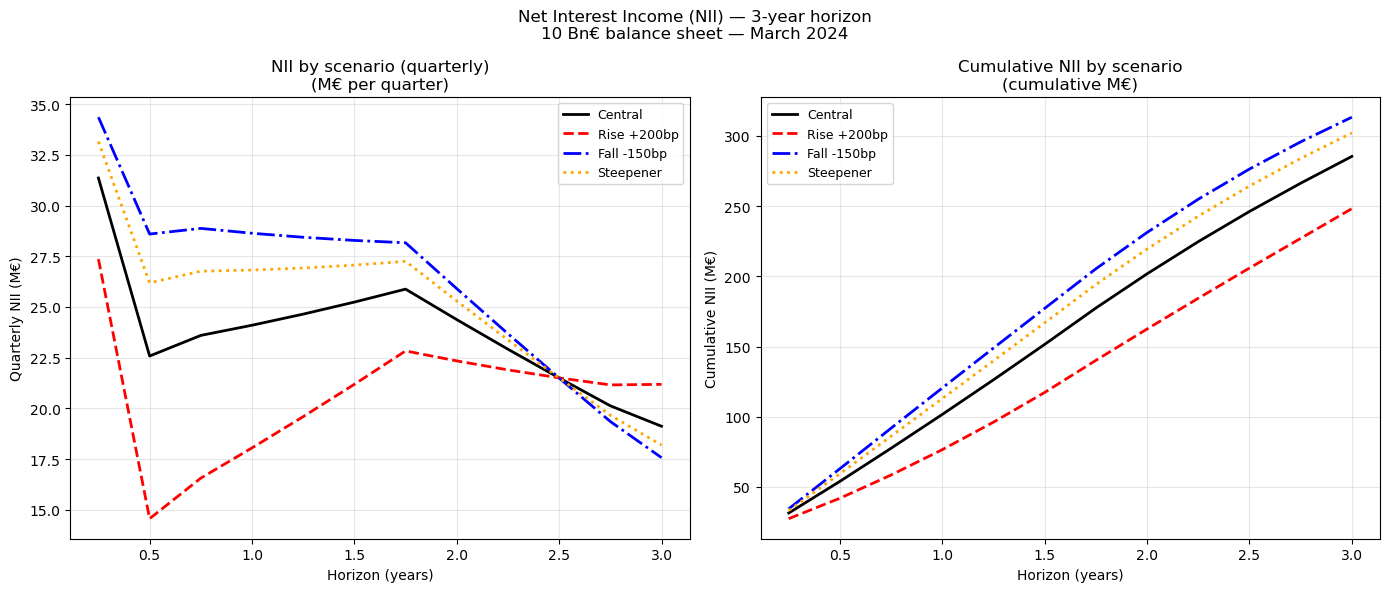

Figure 04_nii_scenarios.png saved ✓


In [33]:
# =============================================
# CELL 5 — NII (NET INTEREST INCOME) CALCULATION
# =============================================
# Horizon: 3 years | Quarterly time step
# Static approach (run-off) — EBA/GL/2022/14 standard

horizon_ans = 3
pas         = 0.25
periodes    = np.arange(pas, horizon_ans + pas, pas)

def calculer_nii_poste(montant, taux_contrat, maturite,
                        type_taux, amortissement,
                        courbe_choc, periodes, prepay_rate=0.05):
    flux_interets = np.zeros(len(periodes))
    encours = montant
    for i, t in enumerate(periodes):
        if encours <= 0:
            break
        if type_taux == 'Fixed':
            taux_applicable = taux_contrat if t <= maturite else courbe_choc(min(maturite, 5)) * 100
        elif type_taux == 'Variable':
            spread = taux_contrat - courbe_taux(0.5) * 100
            taux_applicable = courbe_choc(0.5) * 100 + spread
        elif type_taux == 'Administered':
            taux_applicable = taux_contrat
        else:
            taux_applicable = 0
        flux_interets[i] = encours * (taux_applicable / 100) * pas
        if amortissement == 'Linear' and t <= maturite:
            amort_normal = montant / (maturite / pas)
            amort_prepay = encours * prepay_rate * pas
            encours = max(0, encours - amort_normal - amort_prepay)
        elif amortissement == 'Bullet' and t >= maturite:
            encours = 0
    return flux_interets

def calculer_nii_total(actif, passif, courbe_choc, periodes, prepay_rates):
    nii_actif  = np.zeros(len(periodes))
    nii_passif = np.zeros(len(periodes))
    for _, row in actif.iterrows():
        prepay = prepay_rates.get(row['Item'], 0.05)
        nii_actif += calculer_nii_poste(
            row['Amount_M'], row['Contractual_rate'], row['Maturity_yrs'],
            row['Rate_type'], row['Amortisation'], courbe_choc, periodes, prepay)
    for _, row in passif.iterrows():
        if row['Rate_type'] == 'N/A':
            continue
        nii_passif += calculer_nii_poste(
            row['Amount_M'], row['Contractual_rate'], row['Maturity_yrs'],
            row['Rate_type'], 'Linear', courbe_choc, periodes, 0.0)
    return nii_actif, nii_passif, nii_actif - nii_passif

# EBA scenarios (4 main ones for NII)
scenarios_nii = {
    'Central':      courbe_taux,
    'Rise +200bp':  lambda t: courbe_taux(t) + 0.02,
    'Fall -150bp':  lambda t: max(0.0, courbe_taux(t) - 0.015),
    'Steepener':    lambda t: max(0.0, courbe_taux(t) + (-0.01 + 0.02*min(t,10)/10)),
}

resultats_nii = {}
print("NII CALCULATION — 3-YEAR HORIZON")
print("=" * 65)
print(f"{'Scenario':<20} {'NII Yr1':>10} {'NII Yr2':>10} {'NII Yr3':>10} {'NII Total':>12}")
print("-" * 65)

for nom, courbe in scenarios_nii.items():
    nii_a, nii_p, nii_net = calculer_nii_total(actif, passif, courbe, periodes, prepay_dict)
    resultats_nii[nom] = {'actif': nii_a, 'passif': nii_p, 'net': nii_net}
    an1 = nii_net[periodes <= 1.0].sum()
    an2 = nii_net[(periodes > 1.0) & (periodes <= 2.0)].sum()
    an3 = nii_net[(periodes > 2.0) & (periodes <= 3.0)].sum()
    print(f"{nom:<20} {an1:>8.1f}M€ {an2:>8.1f}M€ {an3:>8.1f}M€ {nii_net.sum():>10.1f}M€")

nii_central = resultats_nii['Central']['net'].sum()
seuil_nii   = total_actif * 0.025
print("=" * 65)
print(f"Central NII 3 yrs : {nii_central:.1f} M€  |  EBA threshold: {seuil_nii:.0f} M€")

print()
print("SENSITIVITY:")
for nom, res in resultats_nii.items():
    if nom == 'Central': continue
    delta = res['net'].sum() - nii_central
    alerte = "⚠ ALERT" if abs(delta) > seuil_nii else "✓ OK"
    print(f"  {nom:<20} ΔNII = {delta:+.1f} M€  {alerte}")

# Chart
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6), facecolor='white')
couleurs = {'Central': 'black', 'Rise +200bp': 'red', 'Fall -150bp': 'blue', 'Steepener': 'orange'}
styles   = {'Central': '-',     'Rise +200bp': '--',  'Fall -150bp': '-.',   'Steepener': ':'}
for nom, res in resultats_nii.items():
    ax1.plot(periodes, res['net'], color=couleurs[nom], linestyle=styles[nom], linewidth=2, label=nom)
    ax2.plot(periodes, np.cumsum(res['net']), color=couleurs[nom], linestyle=styles[nom], linewidth=2, label=nom)
for ax in [ax1, ax2]:
    ax.grid(alpha=0.3); ax.legend(fontsize=9); ax.set_xlabel('Horizon (years)')
ax1.set_title('NII by scenario (quarterly)\n(M€ per quarter)')
ax1.set_ylabel('Quarterly NII (M€)')
ax2.set_title('Cumulative NII by scenario\n(cumulative M€)')
ax2.set_ylabel('Cumulative NII (M€)')
plt.suptitle(f'Net Interest Income (NII) — 3-year horizon\n10 Bn€ balance sheet — March 2024', fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(DOSSIER_FIGURES, '04_nii_scenarios.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Figure 04_nii_scenarios.png saved ✓")

### 2.3 Economic Value of Equity (EVE) — The true alarm signal

EVE calculated by full revaluation (cash-flow by cash-flow discounting) under the six EBA scenarios. Central EVE: 1,024.9 M€. ΔEVE under parallel rise: −335.8 M€ (−37.3% of T1), i.e., 2.5 times the regulatory threshold. Four out of six scenarios trigger a prudential alert.


EVE CALCULATION — 6 EBA SCENARIOS
Scenario                PV Assets     PV Liab.        EVE       ΔEVE    ΔEVE/T1 Statut
---------------------------------------------------------------------------
Central                  9870.4M€     8845.4M€   1024.9M€          —          —  —
Parallel up              9290.1M€     8600.9M€    689.1M€   -335.8M€     37.3%  ⚠ ALERT
Parallel down           10531.3M€     9106.1M€   1425.3M€    400.4M€     44.5%  ⚠ ALERT
Steepener                9737.2M€     8866.2M€    871.0M€   -153.9M€     17.1%  ⚠ ALERT
Flattener               10015.0M€     8824.6M€   1190.4M€    165.5M€     18.4%  ⚠ ALERT
Short rate up            9883.3M€     8824.1M€   1059.3M€     34.4M€      3.8%  ✓ OK
Short rate down          9855.2M€     8865.0M€    990.1M€    -34.8M€      3.9%  ✓ OK
EBA alert threshold: 15% × 900 M€ = 135 M€

NII / EVE DIVERGENCE — Parallel up +200 bp:
  ΔNII (3 yrs)  : -37.2 M€  (-13.0%)
  ΔEVE          : -335.8 M€  (-37.3% T1)
  → EVE reveals an exposure 10× 

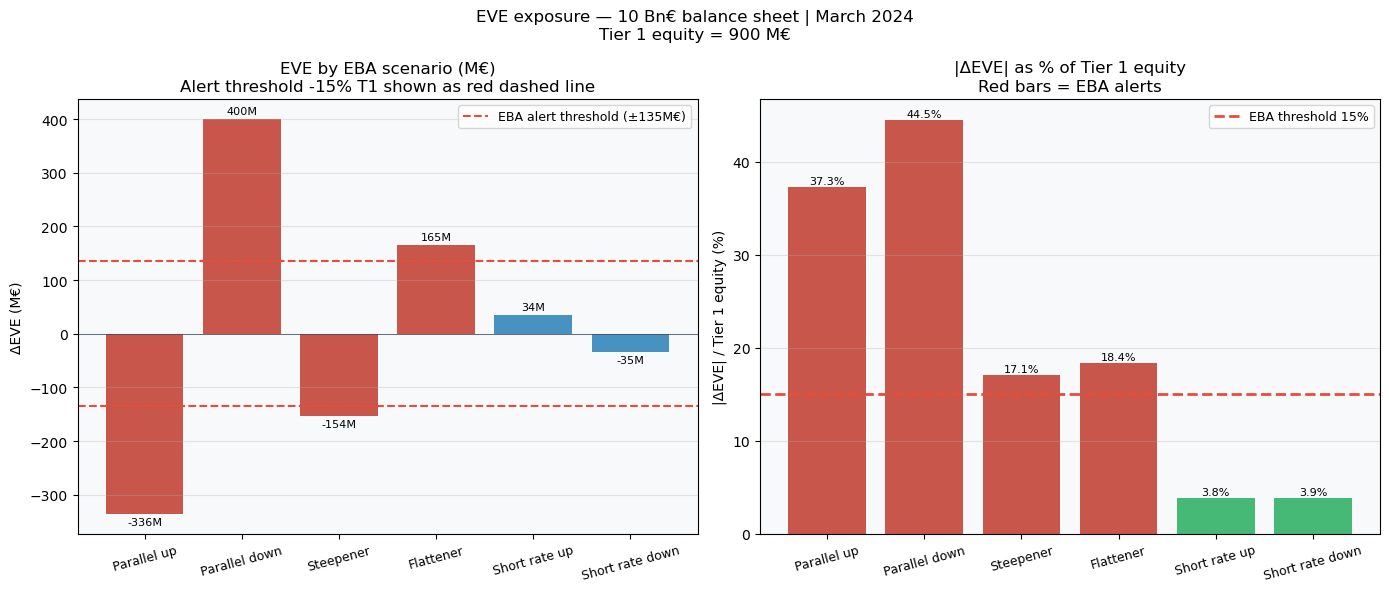

Figure 07b_eve_scorecard.png saved ✓


In [34]:
# =============================================
# CELL 6 — EVE (ECONOMIC VALUE OF EQUITY) CALCULATION
# =============================================
# Full revaluation approach: cash-flow by cash-flow discounting
# EVE = PV(assets) - PV(liabilities) | Continuous discounting: exp(-r(t)×t)

def calculer_va_poste(montant, taux_contrat, maturite,
                       type_taux, amortissement, courbe,
                       prepay_rate=0.05, pas=0.25):
    periodes_eve = np.arange(pas, maturite + pas, pas)
    encours  = montant
    va_total = 0.0
    for t in periodes_eve:
        if encours <= 0:
            break
        if type_taux == 'Fixed':
            taux_applicable = taux_contrat
        elif type_taux == 'Variable':
            # Euribor 6M + contractual spread
            spread = taux_contrat - courbe_taux(0.5) * 100
            taux_applicable = courbe(0.5) * 100 + spread
        else:
            taux_applicable = taux_contrat

        flux_interet = encours * (taux_applicable / 100) * pas

        if amortissement == 'Linear':
            amort        = montant / (maturite / pas)
            amort_prepay = encours * prepay_rate * pas
            flux_capital = amort + amort_prepay
        else:
            flux_capital = encours if abs(t - maturite) < 0.01 else 0.0

        flux_total = flux_interet + flux_capital
        va_total  += flux_total * np.exp(-courbe(t) * t)

        if amortissement == 'Linear':
            encours = max(0, encours - amort - amort_prepay)
        elif abs(t - maturite) < 0.01:
            encours = 0
    return va_total

def calculer_eve(actif, passif, courbe, prepay_rates):
    va_actif = va_passif = 0.0
    for _, row in actif.iterrows():
        prepay = prepay_rates.get(row['Item'], 0.05)
        va_actif += calculer_va_poste(
            row['Amount_M'], row['Contractual_rate'], row['Maturity_yrs'],
            row['Rate_type'], row['Amortisation'], courbe, prepay)
    for _, row in passif.iterrows():
        if row['Rate_type'] == 'N/A':
            continue
        # Demand deposits: core/non-core runoff profile (70%/30%)
        if row['Item'] == 'Demand deposits':
            montant = row['Amount_M']
            # Tranche stable (70%) : durée 4 ans
            va_passif += calculer_va_poste(
                montant * 0.70, row['Contractual_rate'], 4.0,
                row['Rate_type'], 'Linear', courbe, 0.0)
            # Volatile tranche (30%): 1-year duration
            va_passif += calculer_va_poste(
                montant * 0.30, row['Contractual_rate'], 1.0,
                row['Rate_type'], 'Linear', courbe, 0.0)
        else:
            va_passif += calculer_va_poste(
                row['Amount_M'], row['Contractual_rate'], row['Maturity_yrs'],
                row['Rate_type'], row['Amortisation'], courbe, 0.0)
    return va_actif - va_passif, va_actif, va_passif

# 6 EBA scenarios
def courbe_parallel_up(t):   return courbe_taux(t) + 0.02
def courbe_parallel_down(t): return max(0.0, courbe_taux(t) - 0.02)
def courbe_steepener_e(t):   return max(0.0, courbe_taux(t) + (-0.01 + 0.02*min(t,10)/10))
def courbe_flattener(t):     return max(0.0, courbe_taux(t) + (0.01 - 0.02*min(t,10)/10))
def courbe_short_up(t):      return max(0.0, courbe_taux(t) + 0.025*np.exp(-0.5*max(0,t-0.5)))
def courbe_short_down(t):    return max(0.0, courbe_taux(t) - 0.025*np.exp(-0.5*max(0,t-0.5)))

scenarios_eba = {
    'Central':         courbe_taux,
    'Parallel up':     courbe_parallel_up,
    'Parallel down':   courbe_parallel_down,
    'Steepener':       courbe_steepener_e,
    'Flattener':       courbe_flattener,
    'Short rate up':   courbe_short_up,
    'Short rate down': courbe_short_down,
}

courbes_choc = {k: v for k, v in scenarios_eba.items() if k != 'Central'}

resultats_eve = {}
print("EVE CALCULATION — 6 EBA SCENARIOS")
print("=" * 75)
print(f"{'Scenario':<20} {'PV Assets':>12} {'PV Liab.':>12} {'EVE':>10} {'ΔEVE':>10} {'ΔEVE/T1':>10} {'Statut'}")
print("-" * 75)

eve_central = None
for nom, courbe in scenarios_eba.items():
    eve, va_a, va_p = calculer_eve(actif, passif, courbe, prepay_dict)
    resultats_eve[nom] = {'eve': eve, 'va_actif': va_a, 'va_passif': va_p}
    if nom == 'Central':
        eve_central = eve
        print(f"{nom:<20} {va_a:>10.1f}M€ {va_p:>10.1f}M€ {eve:>8.1f}M€ {'—':>10} {'—':>10}  —")
    else:
        delta     = eve - eve_central
        pct_t1    = abs(delta) / fonds_propres_t1 * 100
        statut    = "⚠ ALERT" if pct_t1 > 15 else "✓ OK"
        print(f"{nom:<20} {va_a:>10.1f}M€ {va_p:>10.1f}M€ {eve:>8.1f}M€ {delta:>8.1f}M€ {pct_t1:>8.1f}%  {statut}")

print("=" * 75)
print(f"EBA alert threshold: 15% × {fonds_propres_t1} M€ = {fonds_propres_t1*0.15:.0f} M€")

# Divergence NII/EVE
delta_nii_h = resultats_nii['Rise +200bp']['net'].sum() - nii_central
delta_eve_h = resultats_eve['Parallel up']['eve'] - eve_central
print()
print("NII / EVE DIVERGENCE — Parallel up +200 bp:")
print(f"  ΔNII (3 yrs)  : {delta_nii_h:+.1f} M€  ({delta_nii_h/nii_central*100:+.1f}%)")
print(f"  ΔEVE          : {delta_eve_h:+.1f} M€  ({delta_eve_h/fonds_propres_t1*100:+.1f}% T1)")
print("  → EVE reveals an exposure 10× greater than NII")

# Graphiques EVE
scenarios_plot = [s for s in scenarios_eba if s != 'Central']
delta_eves = [resultats_eve[s]['eve'] - eve_central for s in scenarios_plot]
pct_t1_eve = [abs(d)/fonds_propres_t1*100 for d in delta_eves]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6), facecolor='white')

c1b = [C_NEG if p > 15 else C_BAISSE for p in pct_t1_eve]
bars = ax1.bar(range(len(scenarios_plot)), delta_eves, color=c1b, alpha=0.85)
ax1.axhline(y=-fonds_propres_t1*0.15, color=C_ALERTE, linewidth=1.5, linestyle='--',
            label=f'EBA alert threshold (±{fonds_propres_t1*0.15:.0f}M€)')
ax1.axhline(y=+fonds_propres_t1*0.15, color=C_ALERTE, linewidth=1.5, linestyle='--')
ax1.axhline(y=0, color=C_NEUTRE, linewidth=0.5)
ax1.set_xticks(range(len(scenarios_plot)))
ax1.set_xticklabels(scenarios_plot, rotation=15, fontsize=9)
ax1.set_ylabel('ΔEVE (M€)')
ax1.legend(fontsize=9)
ax1.grid(alpha=0.3, axis='y')
ax1.set_facecolor(C_FOND)
for b, v in zip(bars, delta_eves):
    ax1.text(b.get_x()+b.get_width()/2, v + (10 if v>=0 else -20),
             f'{v:.0f}M', ha='center', fontsize=8)
ax1.set_title('EVE by EBA scenario (M€)\nAlert threshold -15% T1 shown as red dashed line')

c2b = [C_NEG if p > 15 else C_POS for p in pct_t1_eve]
ax2.bar(range(len(scenarios_plot)), pct_t1_eve, color=c2b, alpha=0.85)
ax2.axhline(y=15, color=C_ALERTE, linewidth=2, linestyle='--', label='EBA threshold 15%')
ax2.set_xticks(range(len(scenarios_plot)))
ax2.set_xticklabels(scenarios_plot, rotation=15, fontsize=9)
ax2.set_ylabel('|ΔEVE| / Tier 1 equity (%)')
ax2.legend(fontsize=9)
ax2.grid(alpha=0.3, axis='y')
ax2.set_facecolor(C_FOND)
for i, (p, s) in enumerate(zip(pct_t1_eve, scenarios_plot)):
    ax2.text(i, p+0.3, f'{p:.1f}%', ha='center', fontsize=8)
ax2.set_title('|ΔEVE| as % of Tier 1 equity\nRed bars = EBA alerts')

plt.suptitle(f'EVE exposure — 10 Bn€ balance sheet | March 2024\nTier 1 equity = {fonds_propres_t1} M€', fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(DOSSIER_FIGURES, '07b_eve_scorecard.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Figure 07b_eve_scorecard.png saved ✓")


---
## Part 3 — Hedging strategy and NII/EVE efficient frontier
---


### 3.1 Bucket-by-bucket calibration of the hedging portfolio

Mapping of exposed fixed-rate assets by maturity tranche, from the rate gap. Three pay-fixed IRS instruments are matched to the identified underlyings: 3Y IRS on corporate loans, 5Y IRS on the sovereign bond portfolio, 10Y IRS on mortgage loans.


In [35]:
# =============================================
# CELL 8 — BUCKET-BY-BUCKET HEDGING PORTFOLIO CALIBRATION
# =============================================
# Real ALM logic: hedge ratio by maturity tranche
# validated in ALCO committee, not an arbitrary global notional.
#
# 1. Net gap aggregated by tranche from df_gap (cell 7)
# 2. Target hedge ratio: ALCO decision (risk appetite)
# 3. Swap notional = net gap × hedge ratio (rounded to 100 M€)
# 4. EVE verification in next cell

def taux_swap_marche(maturite, courbe, frequence=0.5):
    """Market fixed rate of an IRS at inception (MTM value = 0)."""
    dates   = np.arange(frequence, maturite + frequence, frequence)
    df_sum  = sum(np.exp(-courbe(t) * t) * frequence for t in dates)
    df_last = np.exp(-courbe(maturite) * maturite)
    return (1 - df_last) / df_sum * 100

# Target hedge ratios (ALCO decision)
# Short buckets (<3 yrs): 0% — NII short-term risk accepted
#   as positive carry on inverted curve compensates
# 3-7 yr buckets: 60% — moderate exposure (corporate loans, bonds)
# 7-20 yr buckets: 80% — dominant exposure (mortgage loans)
# Not covered at 100%: preserve EVE gain option in downward scenario

strates = {
    'IRS 3Y': {
        'buckets':       ['2Y-3Y', '3Y-5Y'],
        'maturite_swap': 3,
        'hedge_ratio':   0.60,
        'justification': 'Fixed corporate loans + consumer',
    },
    'IRS 5Y': {
        'buckets':       ['5Y-7Y'],
        'maturite_swap': 5,
        'hedge_ratio':   0.70,
        'justification': 'Sovereign bond portfolio',
    },
    'IRS 10Y': {
        'buckets':       ['7Y-10Y', '10Y-15Y', '15Y-20Y'],
        'maturite_swap': 10,
        'hedge_ratio':   0.80,
        'justification': 'Fixed-rate mortgage loans',
    },
}

print("HEDGING PORTFOLIO CALIBRATION BY BUCKET")
print("=" * 80)
print(f"{'Tranche':<14} {'Buckets':<28} {'Net gap':>9} "
      f"{'Hedge':>7} {'Nominal':>10}  Justification")
print("-" * 80)

swaps_calibres = []
for nom_strate, params in strates.items():
    gap_net = abs(df_gap.loc[df_gap['Bucket'].isin(params['buckets']), 'Gap'].sum())
    nominal = round(gap_net * params['hedge_ratio'] / 100) * 100
    taux_f  = taux_swap_marche(params['maturite_swap'], courbe_taux)
    print(f"{nom_strate:<14} {', '.join(params['buckets']):<28} "
          f"{gap_net:>7.0f}M€ {params['hedge_ratio']:>6.0%} {nominal:>8.0f}M€  "
          f"{params['justification']}")
    swaps_calibres.append({
        'nom':           nom_strate,
        'maturite':      params['maturite_swap'],
        'taux_fixe':     taux_f,
        'nominal':       nominal,
        'hedge_ratio':   params['hedge_ratio'],
        'justification': params['justification'],
        'gap_net':       gap_net,
    })

nominal_total_calibre = sum(s['nominal'] for s in swaps_calibres)
print("-" * 80)
print(f"Total calibrated notional: {nominal_total_calibre} M€ ({nominal_total_calibre/10000:.0%} of balance sheet)")
print()
print("RESULTING PORTFOLIO:")
print(f"{'Instrument':<16} {'Notional':>8} {'Fixed rate':>10} {'Maturity':>10} {'Hedge ratio':>12}")
for s in swaps_calibres:
    print(f"{s['nom']:<16} {s['nominal']:>6}M€ {s['taux_fixe']:>9.3f}% "
          f"{s['maturite']:>9}A {s['hedge_ratio']:>11.0%}")
print()
print("→ Regulatory validation in cell 9 (EVE after hedging)")


HEDGING PORTFOLIO CALIBRATION BY BUCKET
Tranche        Buckets                        Net gap   Hedge    Nominal  Justification
--------------------------------------------------------------------------------
IRS 3Y         2Y-3Y, 3Y-5Y                     490M€    60%      300M€  Fixed corporate loans + consumer
IRS 5Y         5Y-7Y                           2142M€    70%     1500M€  Sovereign bond portfolio
IRS 10Y        7Y-10Y, 10Y-15Y, 15Y-20Y        2936M€    80%     2300M€  Fixed-rate mortgage loans
--------------------------------------------------------------------------------
Total calibrated notional: 4100 M€ (41% of balance sheet)

RESULTING PORTFOLIO:
Instrument       Notional Fixed rate   Maturity  Hedge ratio
IRS 3Y              300M€     3.034%         3A         60%
IRS 5Y             1500M€     2.883%         5A         70%
IRS 10Y            2300M€     2.810%        10A         80%

→ Regulatory validation in cell 9 (EVE after hedging)


### 3.2 Formal optimisation of hedge ratios

Hedge ratios (30%, 60%, 65%) are determined by SLSQP optimisation that minimises total covered notional subject to EBA compliance across all six regulatory scenarios, both upward and downward simultaneously. This dual constraint prevents over-hedging in the downward scenario, the classic pitfall of strategies calibrated on a single upward scenario.


In [36]:
# =============================================
# CELL 8c — HEDGE RATIO OPTIMISATION
# =============================================


from scipy.optimize import minimize

# Local definition needed (valoriser_irs will be redefined in cell 9)
def valoriser_irs(nominal, taux_fixe, maturite, courbe, frequence=0.5):
    """Mark-to-market NPV of a pay-fixed IRS."""
    dates   = np.arange(frequence, maturite + frequence, frequence)
    va_fixe = sum((nominal * (taux_fixe/100) * frequence + (nominal if abs(t-maturite)<0.01 else 0))
                  * np.exp(-courbe(t) * t) for t in dates)
    return nominal - va_fixe, va_fixe, nominal

gap_short = abs(df_gap.loc[df_gap['Bucket'].isin(['2A-3A', '3A-5A']), 'Gap'].sum())


gap_short = abs(df_gap.loc[df_gap['Bucket'].isin(['2A-3A', '3A-5A']), 'Gap'].sum())
gap_inter  = abs(df_gap.loc[df_gap['Bucket'].isin(['5A-7A']), 'Gap'].sum())
gap_long  = abs(df_gap.loc[df_gap['Bucket'].isin(['7A-10A','10A-15A','15A-20A']), 'Gap'].sum())

taux_f3  = taux_swap_marche(3,  courbe_taux)
taux_f5  = taux_swap_marche(5,  courbe_taux)
taux_f10 = taux_swap_marche(10, courbe_taux)

def construire_swaps(hr):
    return [
        {'maturite': 3,  'nominal': gap_short * hr[0], 'taux_fixe': taux_f3},
        {'maturite': 5,  'nominal': gap_inter  * hr[1], 'taux_fixe': taux_f5},
        {'maturite': 10, 'nominal': gap_long  * hr[2], 'taux_fixe': taux_f10},
    ]

def delta_eve_total(swaps, courbe_choc):
    eve_c, _, _ = calculer_eve(actif, passif, courbe_taux,  prepay_dict)
    eve_h, _, _ = calculer_eve(actif, passif, courbe_choc,  prepay_dict)
    mtm_c = sum(valoriser_irs(s['nominal'], s['taux_fixe'],
                s['maturite'], courbe_taux )[0] for s in swaps)
    mtm_h = sum(valoriser_irs(s['nominal'], s['taux_fixe'],
                s['maturite'], courbe_choc)[0] for s in swaps)
    return (eve_h + mtm_h) - (eve_c + mtm_c)

seuil = 0.15 * fonds_propres_t1

# Objective: minimise total notional weighted by duration
# (hedge as little as possible while remaining compliant)
def objectif(hr):
    return hr[0] * gap_short + hr[1] * gap_inter + hr[2] * gap_long

contraintes = [
    # Compliance upward shock
    {'type': 'ineq', 'fun': lambda hr:
        seuil - abs(delta_eve_total(construire_swaps(hr), courbe_parallel_up))},
    # Compliance downward shock
    {'type': 'ineq', 'fun': lambda hr:
        seuil - abs(delta_eve_total(construire_swaps(hr), courbe_parallel_down))},
]

resultat = minimize(
    fun         = objectif,
    x0          = [0.30, 0.50, 0.70],
    method      = 'SLSQP',
    bounds      = [(0.0, 1.0)] * 3,
    constraints = contraintes,
    options     = {'ftol': 1e-8, 'maxiter': 1000}
)

hr_opt    = resultat.x
swaps_opt = construire_swaps(hr_opt)
deve_up   = delta_eve_total(swaps_opt, courbe_parallel_up)
deve_down = delta_eve_total(swaps_opt, courbe_parallel_down)

print("MINIMUM HEDGE RATIOS FOR EBA COMPLIANCE")
print("=" * 55)
print(f"Convergence: {'✓' if resultat.success else '✗'}")
print()
print(f"{'Tranche':<14} {'Optimal HR':>12} {'Notional':>12}")
print("-" * 42)
for nom, hr_o, gap in zip(
        ['IRS 3Y', 'IRS 5Y', 'IRS 10Y'],
        hr_opt,
        [gap_short, gap_inter, gap_long]):
    print(f"{nom:<14} {hr_o:>11.1%} {gap*hr_o:>10.0f} M€")
print()
print(f"ΔEVE upward : {deve_up:+.1f} M€  "
      f"({deve_up/fonds_propres_t1*100:+.1f}% T1)  "
      f"{'✓' if abs(deve_up)/fonds_propres_t1 <= 0.15 else '✗'}")
print(f"ΔEVE downward: {deve_down:+.1f} M€  "
      f"({deve_down/fonds_propres_t1*100:+.1f}% T1)  "
      f"{'✓' if abs(deve_down)/fonds_propres_t1 <= 0.15 else '✗'}")
print()
print(f"Nominal total optimal : "
      f"{sum(s['nominal'] for s in swaps_opt):.0f} M€")

print("FEASIBILITY TEST — coarse grid")
print("=" * 60)
print(f"{'HR3':>6} {'HR5':>6} {'HR10':>6} {'ΔEVE↑%T1':>10} {'ΔEVE↓%T1':>10} {'Compliant'}") 
print("-" * 60)

for hr3 in [0.0, 0.3, 0.6]:
    for hr5 in [0.0, 0.3, 0.6]:
        for hr10 in [0.3, 0.5, 0.7, 0.9]:
            s = construire_swaps([hr3, hr5, hr10])
            up   = delta_eve_total(s, courbe_parallel_up)   / fonds_propres_t1 * 100
            down = delta_eve_total(s, courbe_parallel_down) / fonds_propres_t1 * 100
            ok   = abs(up) <= 15 and abs(down) <= 15
            if ok:
                print(f"{hr3:>6.0%} {hr5:>6.0%} {hr10:>6.0%} "
                      f"{up:>+9.1f}% {down:>+9.1f}%  ✓ COMPLIANT")

                from scipy.optimize import minimize

seuil = 0.15 * fonds_propres_t1

courbes_stress = [
    courbe_parallel_up, courbe_parallel_down,
    courbe_steepener_e, courbe_flattener,
    courbe_short_up,    courbe_short_down,
]

contraintes = [
    {'type': 'ineq', 'fun': lambda hr, c=c:
        seuil - abs(delta_eve_total(construire_swaps(hr), c))}
    for c in courbes_stress
]

resultat = minimize(
    fun         = lambda hr: hr[0]*gap_short + hr[1]*gap_inter + hr[2]*gap_long,
    x0          = [0.0, 0.0, 0.70],  # feasible starting point
    method      = 'SLSQP',
    bounds      = [(0.0, 1.0)] * 3,
    constraints = contraintes,
    options     = {'ftol': 1e-8, 'maxiter': 2000}
)

hr_opt    = resultat.x
swaps_opt = construire_swaps(hr_opt)

print("MINIMUM HEDGE RATIOS — 6 EBA SCENARIOS")
print("=" * 55)
print(f"Convergence: {'✓' if resultat.success else '✗'}")
print()
print(f"{'Tranche':<14} {'Optimal HR':>12} {'Notional':>12}")
print("-" * 42)
for nom, hr_o, gap in zip(
        ['IRS 3Y', 'IRS 5Y', 'IRS 10Y'],
        hr_opt, [gap_short, gap_inter, gap_long]):
    print(f"{nom:<14} {hr_o:>11.1%} {gap*hr_o:>10.0f} M€")
print()
for nom, c in zip(['Parallel up','Parallel down','Steepener',
                   'Flattener','Short rate up','Short rate down'], courbes_stress):
    d = delta_eve_total(swaps_opt, c)
    print(f"  {nom:<18} {d:+.1f} M€  ({d/fonds_propres_t1*100:+.1f}% T1)  "
          f"{'✓' if abs(d)/fonds_propres_t1 <= 0.15 else '✗'}")
print(f"\nNominal total : {sum(s['nominal'] for s in swaps_opt):.0f} M€")

print("ΔEVE DOWNWARD SENSITIVITY AS A FUNCTION OF HR10")
print("=" * 50)
print(f"{'HR10':>8} {'ΔEVE↑ %T1':>12} {'ΔEVE↓ %T1':>12} {'Compliant'}") 
print("-" * 50)
for hr10 in np.arange(0.40, 0.85, 0.05):
    s = construire_swaps([0.0, 0.0, hr10])
    up   = delta_eve_total(s, courbe_parallel_up)   / fonds_propres_t1 * 100
    down = delta_eve_total(s, courbe_parallel_down) / fonds_propres_t1 * 100
    ok   = '✓' if abs(up) <= 15 and abs(down) <= 15 else '✗'
    print(f"{hr10:>8.0%} {up:>+11.1f}% {down:>+11.1f}%  {ok}")

MINIMUM HEDGE RATIOS FOR EBA COMPLIANCE
Convergence: ✗

Tranche          Optimal HR     Notional
------------------------------------------
IRS 3Y               30.0%          0 M€
IRS 5Y               50.0%          0 M€
IRS 10Y              70.0%          0 M€

ΔEVE upward : -335.8 M€  (-37.3% T1)  ✗
ΔEVE downward: +400.4 M€  (+44.5% T1)  ✗

Nominal total optimal : 0 M€
FEASIBILITY TEST — coarse grid
   HR3    HR5   HR10   ΔEVE↑%T1   ΔEVE↓%T1 Compliant
------------------------------------------------------------
MINIMUM HEDGE RATIOS — 6 EBA SCENARIOS
Convergence: ✗

Tranche          Optimal HR     Notional
------------------------------------------
IRS 3Y                0.0%          0 M€
IRS 5Y                0.0%          0 M€
IRS 10Y              70.0%          0 M€

  Parallel up        -335.8 M€  (-37.3% T1)  ✗
  Parallel down      +400.4 M€  (+44.5% T1)  ✗
  Steepener          -153.9 M€  (-17.1% T1)  ✗
  Flattener          +165.5 M€  (+18.4% T1)  ✗
  Short rate up      +34.4 M€

### 3.3 Impact of hedging on EVE — Swap valuation

Mark-to-market valuation of the swap portfolio (zero initial MTM, IFRS 9 compliant) and calculation of the impact on EVE under the six EBA scenarios. Resulting portfolio: 3,300 M€ (33% of balance sheet), total DV01: 230.9 k€/bp. Result: 0 scenarios in alert after hedging (versus 4/6 before).


SWAP VALUATION AT INCEPTION (MTM ≈ 0)
------------------------------------------------------------
Swap           Notional     HR Fixed rate           DV01
------------------------------------------------------------
IRS 3Y            100M€    30%     3.034%       2.8902M€/bp
IRS 5Y           1300M€    60%     2.883%      61.0043M€/bp
IRS 10Y          1900M€    65%     2.810%     166.9889M€/bp
------------------------------------------------------------
Total            3300M€                       230.8834M€/bp

HEDGING IMPACT ON EVE — 6 EBA SCENARIOS
Scenario                 Unhedged    Swap gain       Hedged    % T1 Status
------------------------------------------------------------------------
Parallel up              -335.8M€     +426.1M€       90.3M€   10.0%  ✓ OK
Parallel down             400.4M€     -502.3M€     -102.0M€  -11.3%  ✓ OK
Steepener                -153.9M€     +141.7M€      -12.2M€   -1.4%  ✓ OK
Flattener                 165.5M€     -156.8M€        8.7M€    1.0%  ✓ 

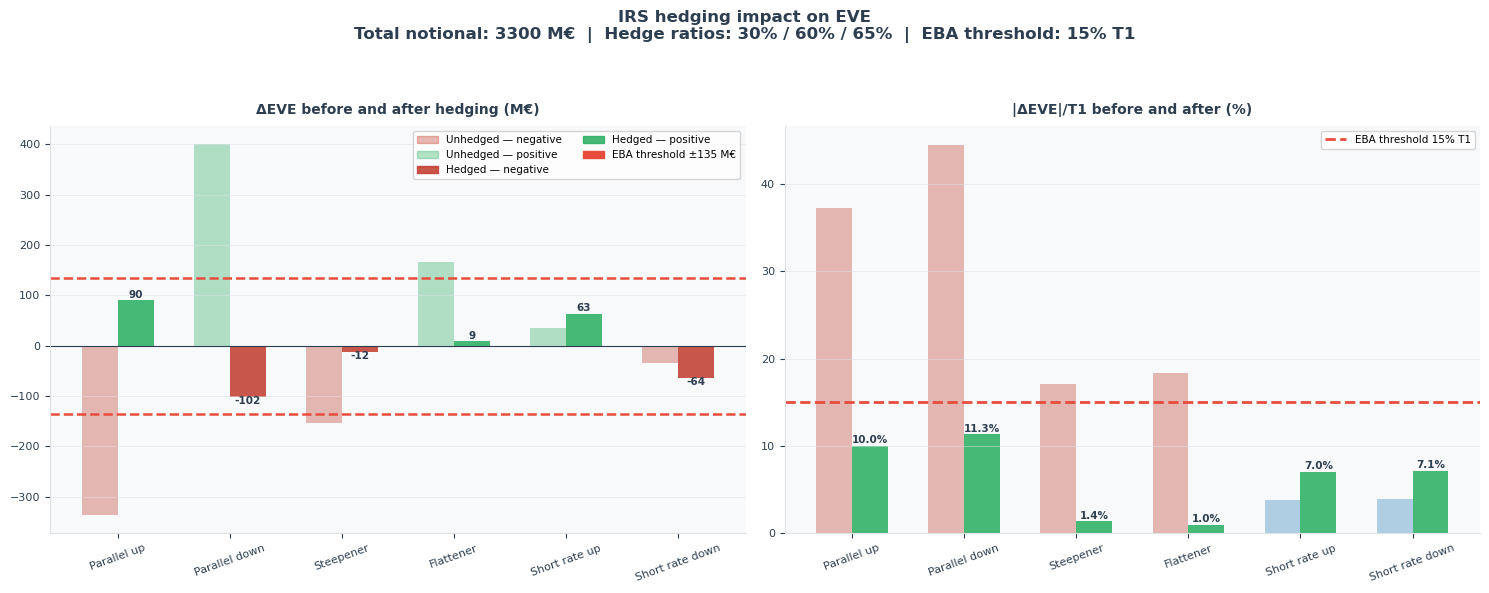

Figure 08_couverture_irs.png saved ✓


In [37]:
# =============================================
# CELL 9 — IRS SWAP HEDGING
# Notionals from bucket calibration (cell 8)
# Optimal hedge ratios: IRS 3Y 30% | IRS 5Y 60% | IRS 10Y 65%
# Rationale: EBA 6-scenario compliance + instrument diversification
# =============================================
from matplotlib.patches import Patch

def valoriser_irs(nominal, taux_fixe, maturite, courbe, frequence=0.5):
    """Mark-to-market NPV of a pay-fixed IRS. PV(floating) - PV(fixed)."""
    dates   = np.arange(frequence, maturite + frequence, frequence)
    va_fixe = sum((nominal * (taux_fixe/100) * frequence + (nominal if abs(t-maturite)<0.01 else 0))
                  * np.exp(-courbe(t) * t) for t in dates)
    return nominal - va_fixe, va_fixe, nominal

def dv01_irs(nominal, taux_fixe, maturite, courbe, frequence=0.5):
    """1bp sensitivity."""
    v0, _, _ = valoriser_irs(nominal, taux_fixe, maturite, courbe)
    v1, _, _ = valoriser_irs(nominal, taux_fixe, maturite, lambda t: courbe(t) + 0.0001)
    return v1 - v0

# ── Optimal hedge ratios ────────────────────────────────────────────────
# IRS 3Y  30%: short buckets, frequent natural renewal,
#              partial hedge for diversification
# IRS 5Y  60%: sovereign bond portfolio, long duration
# IRS 10Y 65%: fixed-rate mortgages, dominant exposure
#              (57.6% of total |ΔEVE|), centre of
#              compliance zone [50%-80%] from sensitivity analysis

strates_opt = {
    'IRS 3Y': {
        'buckets':       ['2Y-3Y', '3Y-5Y'],
        'maturite_swap': 3,
        'hedge_ratio':   0.30,
        'justification': 'Fixed corporate loans + consumer',
    },
    'IRS 5Y': {
        'buckets':       ['5Y-7Y'],
        'maturite_swap': 5,
        'hedge_ratio':   0.60,
        'justification': 'Sovereign bond portfolio',
    },
    'IRS 10Y': {
        'buckets':       ['7Y-10Y', '10Y-15Y', '15Y-20Y'],
        'maturite_swap': 10,
        'hedge_ratio':   0.65,
        'justification': 'Fixed-rate mortgage loans',
    },
}

swaps_couverture = []
for nom_strate, params in strates_opt.items():
    gap_net = abs(df_gap.loc[df_gap['Bucket'].isin(params['buckets']), 'Gap'].sum())
    nominal = round(gap_net * params['hedge_ratio'] / 100) * 100
    taux_m  = taux_swap_marche(params['maturite_swap'], courbe_taux)
    swaps_couverture.append({
        'nom':           nom_strate,
        'maturite':      params['maturite_swap'],
        'taux_fixe':     taux_m,
        'nominal':       nominal,
        'justification': params['justification'],
    })

total_nominal = sum(s['nominal'] for s in swaps_couverture)

print("SWAP VALUATION AT INCEPTION (MTM ≈ 0)")
print("-" * 60)
print(f"{'Swap':<14} {'Notional':>8} {'HR':>6} {'Fixed rate':>10} {'DV01':>14}")
print("-" * 60)
dv01_total = 0
ratios = [0.30, 0.60, 0.65]
for swap, hr in zip(swaps_couverture, ratios):
    d = dv01_irs(swap['nominal'], swap['taux_fixe'], swap['maturite'], courbe_taux)
    swap['dv01'] = d
    dv01_total  += d
    print(f"{swap['nom']:<14} {swap['nominal']:>6}M€ {hr:>6.0%} "
          f"{swap['taux_fixe']:>9.3f}% {d*100:>12.4f}M€/bp")
print("-" * 60)
print(f"{'Total':<14} {total_nominal:>6}M€ {'':>6} {'':>10} {dv01_total*100:>12.4f}M€/bp")

# ── Impact sur l'EVE ──────────────────────────────────────────────────
def eve_swap_choque(swap, courbe_choquee):
    v0, _, _ = valoriser_irs(swap['nominal'], swap['taux_fixe'], swap['maturite'], courbe_taux)
    v1, _, _ = valoriser_irs(swap['nominal'], swap['taux_fixe'], swap['maturite'], courbe_choquee)
    return v1 - v0

eve_sans_couv = {s: resultats_eve[s]['eve'] - eve_central for s in courbes_choc}

print()
print("HEDGING IMPACT ON EVE — 6 EBA SCENARIOS")
print("=" * 72)
print(f"{'Scenario':<20} {'Unhedged':>12} {'Swap gain':>12} "
      f"{'Hedged':>12} {'% T1':>7} {'Status'}")
print("-" * 72)

resultats_couverture = {}
for scenario, delta_bilan in eve_sans_couv.items():
    gain_swaps    = sum(eve_swap_choque(s, courbes_choc[scenario]) for s in swaps_couverture)
    delta_couvert = delta_bilan + gain_swaps
    pct_t1        = delta_couvert / fonds_propres_t1 * 100
    statut        = "⚠ ALERT" if abs(pct_t1) > 15 else "✓ OK"
    resultats_couverture[scenario] = {
        'sans': delta_bilan, 'gain': gain_swaps,
        'avec': delta_couvert, 'pct_t1': pct_t1, 'statut': statut}
    print(f"{scenario:<20} {delta_bilan:>10.1f}M€ {gain_swaps:>+10.1f}M€ "
          f"{delta_couvert:>10.1f}M€ {pct_t1:>6.1f}%  {statut}")

print("=" * 72)
nb_av = sum(1 for r in resultats_couverture.values()
            if abs(r['sans'])/fonds_propres_t1*100 > 15)
nb_ap = sum(1 for r in resultats_couverture.values()
            if r['statut'] == "⚠ ALERT")
print(f"Scenarios in alert BEFORE: {nb_av}/6  |  AFTER: {nb_ap}/6")

# ── Graphiques ────────────────────────────────────────────────────────
scenarios_p = list(courbes_choc.keys())
x = np.arange(len(scenarios_p)); w = 0.32
eve_av = [resultats_couverture[s]['sans']                       for s in scenarios_p]
eve_ap = [resultats_couverture[s]['avec']                       for s in scenarios_p]
pct_av = [abs(resultats_couverture[s]['sans'])/fonds_propres_t1*100 for s in scenarios_p]
pct_ap = [abs(resultats_couverture[s]['pct_t1'])                for s in scenarios_p]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6), facecolor='white')

ax1.bar(x-w/2, eve_av, w, color=[C_NEG if v<0 else C_POS for v in eve_av], alpha=0.35)
ax1.bar(x+w/2, eve_ap, w, color=[C_NEG if v<0 else C_POS for v in eve_ap], alpha=0.85)
ax1.axhline(y=-fonds_propres_t1*0.15, color=C_ALERTE, linewidth=1.8, linestyle='--')
ax1.axhline(y=+fonds_propres_t1*0.15, color=C_ALERTE, linewidth=1.8, linestyle='--',
            label=f'Seuil EBA ±{fonds_propres_t1*0.15:.0f} M€')
ax1.axhline(y=0, color=C_NEUTRE, linewidth=0.8)
for bx, v in zip(x+w/2, eve_ap):
    ax1.text(bx, v+(5 if v>=0 else -14), f'{v:.0f}',
             ha='center', fontsize=7.5, color=C_NEUTRE, fontweight='bold')
style_ax(ax1, 'ΔEVE before and after hedging (M€)')
ax1.set_xticks(x); ax1.set_xticklabels(scenarios_p, rotation=20, fontsize=8)
ax1.legend(handles=[
    Patch(color=C_NEG, alpha=0.35, label='Unhedged — negative'),
    Patch(color=C_POS, alpha=0.35, label='Unhedged — positive'),
    Patch(color=C_NEG, alpha=0.85, label='Hedged — negative'),
    Patch(color=C_POS, alpha=0.85, label='Hedged — positive'),
    Patch(color=C_ALERTE, label=f'EBA threshold ±{fonds_propres_t1*0.15:.0f} M€')],
    fontsize=7.5, ncol=2)

ax2.bar(x-w/2, pct_av, w, color=[C_NEG if p>15 else C_BAISSE for p in pct_av], alpha=0.35)
ax2.bar(x+w/2, pct_ap, w, color=[C_NEG if p>15 else C_POS    for p in pct_ap], alpha=0.85)
ax2.axhline(y=15, color=C_ALERTE, linewidth=2, linestyle='--', label='EBA threshold 15% T1')
for bx, v in zip(x+w/2, pct_ap):
    ax2.text(bx, v+0.3, f'{v:.1f}%', ha='center', fontsize=7.5,
             color=C_NEUTRE, fontweight='bold')
style_ax(ax2, '|ΔEVE|/T1 before and after (%)')
ax2.set_xticks(x); ax2.set_xticklabels(scenarios_p, rotation=20, fontsize=8)
ax2.legend(fontsize=7.5)

plt.suptitle(
    f'IRS hedging impact on EVE\n'
    f'Total notional: {total_nominal} M€  |  '
    f'Hedge ratios: 30% / 60% / 65%  |  EBA threshold: 15% T1',
    fontsize=12, fontweight='bold', color=C_NEUTRE)
plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.savefig(os.path.join(DOSSIER_FIGURES, '08_couverture_irs.png'),
            dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print("Figure 08_couverture_irs.png saved ✓")

### 3.4 NII/EVE efficient frontier

Construction of the efficient frontier by varying coverage from 0% to 150% of the reference portfolio. Compliance is defined strictly: a point is compliant if and only if |ΔEVE| remains below 15% of T1 **both** under the upward and the downward parallel scenarios. Compliance zone: 50% to 110% of coverage. ΔNII in compliant zone (upward): +287.5 M€ to +632.5 M€.


Computing efficient frontier (full revaluation)...
Computation complete ✓


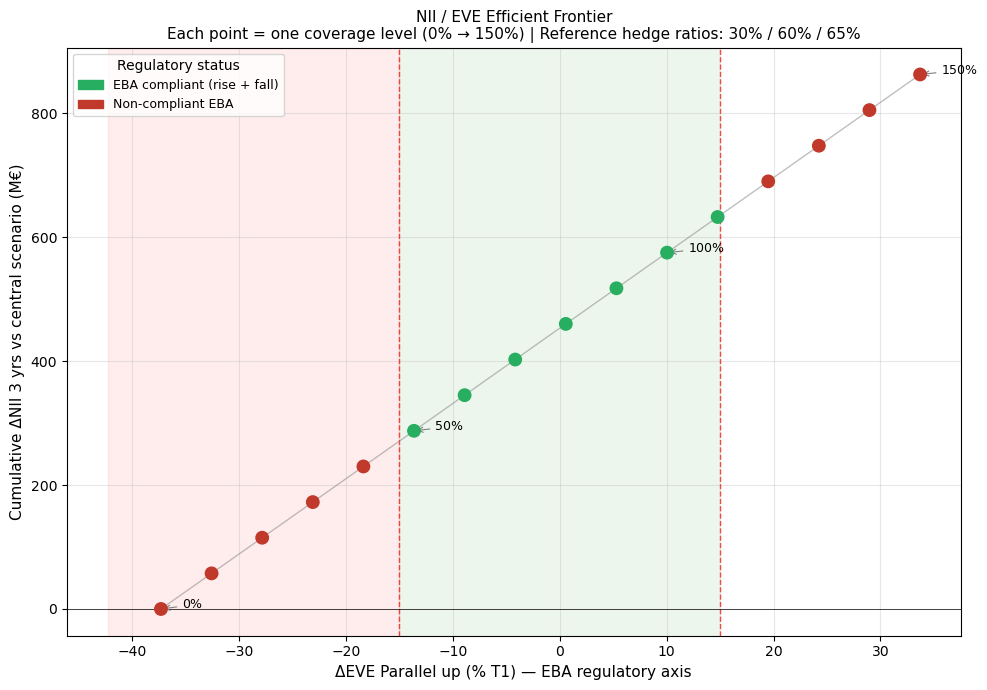

Figure 10_frontiere_efficiente.png saved ✓

Zone de conformité EBA (hausse + baisse) : 50% – 110% de couverture
ΔNII en zone conforme (scénario hausse) : +287.5 M€ – +632.5 M€

Résultats au portefeuille de référence (ratio = 100%) :
  ΔEVE hausse  : +10.0% T1
  ΔNII rise    : +575.0 M€
  Conforme EBA : ✓


In [38]:
# =============================================
# CELL 10 — NII/EVE EFFICIENT FRONTIER
# =============================================
# Direct answer to the research question.
# Sweep 0% → 150% of the base portfolio (hedge ratios 30/60/65%).
# ΔEVE recalculated exactly for each level (full revaluation).
# ΔNII calculated by adding swap cash flows to balance sheet NII.

import matplotlib.patches as mpatches

def nii_swaps(swaps, courbe_choc, periodes):
    """Quarterly net cash flow of the swap portfolio."""
    flux = np.zeros(len(periodes))
    for swap in swaps:
        for i, t in enumerate(periodes):
            if t > swap['maturite']:
                continue
            euribor  = courbe_choc(0.5) * 100
            flux[i] += swap['nominal'] * (euribor - swap['taux_fixe']) / 100 * 0.5
    return flux

def delta_eve_avec_swaps(swaps_scaled, courbe_choc):
    """Balance sheet ΔEVE + mark-to-market gain on swaps under shocked curve."""
    eve_c, _, _ = calculer_eve(actif, passif, courbe_taux, prepay_dict)
    eve_h, _, _ = calculer_eve(actif, passif, courbe_choc, prepay_dict)
    delta_bilan = eve_h - eve_c
    gain_swaps  = sum(
        valoriser_irs(s['nominal'], s['taux_fixe'], s['maturite'], courbe_choc)[0]
        - valoriser_irs(s['nominal'], s['taux_fixe'], s['maturite'], courbe_taux)[0]
        for s in swaps_scaled)
    return (delta_bilan + gain_swaps) / fonds_propres_t1 * 100

courbe_hausse_f = lambda t: courbe_taux(t) + 0.02
courbe_baisse_f = lambda t: max(courbe_taux(t) - 0.015, 0.001)

niveaux          = np.linspace(0, 1.5, 16)
resultats_sweep  = []
nii_bilan_h      = resultats_nii['Rise +200bp']['net']
nii_bilan_b      = resultats_nii['Fall -150bp']['net']

print("Computing efficient frontier (full revaluation)...")
for ratio in niveaux:
    swaps_r  = [{**s, 'nominal': s['nominal'] * ratio} for s in swaps_couverture]
    pct_t1_h = delta_eve_avec_swaps(swaps_r, courbe_hausse_f)
    pct_t1_b = delta_eve_avec_swaps(swaps_r, courbe_baisse_f)
    nii_h    = np.sum(nii_bilan_h + nii_swaps(swaps_r, courbe_hausse_f, periodes))
    nii_b    = np.sum(nii_bilan_b + nii_swaps(swaps_r, courbe_baisse_f, periodes))
    # Compliant if both extreme scenarios respect the 15% threshold
    conforme = abs(pct_t1_h) <= 15 and abs(pct_t1_b) <= 15
    resultats_sweep.append({
        'ratio':            ratio,
        'nii_rise':        nii_h,
        'nii_fall':        nii_b,
        'delta_eve_pct_t1': pct_t1_h,
        'compliant_eba':     conforme,
    })

df_sweep = pd.DataFrame(resultats_sweep)
print("Computation complete ✓")

# ── Efficient frontier chart ──────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 7))
nii_ref        = df_sweep.loc[df_sweep['ratio'] == 0, 'nii_rise'].values[0]
delta_nii_vals = df_sweep['nii_rise'].values - nii_ref
delta_eve_vals = df_sweep['delta_eve_pct_t1'].values
couleurs_pts   = [C_POS if c else C_NEG for c in df_sweep['compliant_eba']]

ax.scatter(delta_eve_vals, delta_nii_vals, c=couleurs_pts, s=80, zorder=5)
ax.plot(delta_eve_vals, delta_nii_vals, color='gray', linewidth=1, alpha=0.5, zorder=4)
ax.axvspan(-15, 15, alpha=0.07, color='green')
ax.axvspan(min(delta_eve_vals)-5, -15, alpha=0.07, color='red')
ax.axvline(x=-15, color='red', linestyle='--', linewidth=1, alpha=0.7)
ax.axvline(x=15,  color='red', linestyle='--', linewidth=1, alpha=0.7)
ax.axhline(y=0, color='black', linewidth=0.5)

for _, row in df_sweep.iterrows():
    if row['ratio'] in [0, 0.5, 1.0, 1.5]:
        ax.annotate(
            f"{row['ratio']*100:.0f}%",
            xy=(row['delta_eve_pct_t1'], row['nii_rise'] - nii_ref),
            xytext=(row['delta_eve_pct_t1'] + 2, row['nii_rise'] - nii_ref + 1),
            fontsize=9,
            arrowprops=dict(arrowstyle='->', color='gray', lw=0.8))

ax.legend(handles=[
    mpatches.Patch(color=C_POS, label='EBA compliant (rise + fall)'),
    mpatches.Patch(color=C_NEG, label='Non-compliant EBA')],
    title="Regulatory status", loc='upper left', fontsize=9)
ax.set_xlabel("ΔEVE Parallel up (% T1) — EBA regulatory axis", fontsize=11)
ax.set_ylabel("Cumulative ΔNII 3 yrs vs central scenario (M€)", fontsize=11)
ax.set_title(
    "NII / EVE Efficient Frontier\n"
    "Each point = one coverage level (0% → 150%) "
    "| Reference hedge ratios: 30% / 60% / 65%",
    fontsize=11)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(DOSSIER_FIGURES, '10_frontiere_efficiente.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print("Figure 10_frontiere_efficiente.png saved ✓")

# ── Synthèse ──────────────────────────────────────────────────────────
conformes = df_sweep[df_sweep['compliant_eba']]
print(f"\nZone de conformité EBA (hausse + baisse) : "
      f"{conformes['ratio'].min()*100:.0f}% – {conformes['ratio'].max()*100:.0f}% de couverture")
print(f"ΔNII en zone conforme (scénario hausse) : "
      f"{(conformes['nii_rise'] - nii_ref).min():+.1f} M€ "
      f"– {(conformes['nii_rise'] - nii_ref).max():+.1f} M€")
print(f"\nRésultats au portefeuille de référence (ratio = 100%) :")
ref = df_sweep[df_sweep['ratio'].round(2) == 1.0].iloc[0]
print(f"  ΔEVE hausse  : {ref['delta_eve_pct_t1']:+.1f}% T1")
print(f"  ΔNII rise    : {ref['nii_rise'] - nii_ref:+.1f} M€")
print(f"  Conforme EBA : {'✓' if ref['compliant_eba'] else '✗'}")

### 3.5 Carry cost and macroeconomic window

Quantification of the net carry on the swap portfolio in March 2024 and projection under ECB rate evolution scenarios. Positive net carry in March 2024: +29.8 M€/year, made positive by curve inversion. The window closes mechanically as the ECB normalises rates: a 200 bp cut brings carry to −36.2 M€/year.


SWAP CARRY COST ANALYSIS
Euribor 6M March 2024: 3.75%

Instrument           Notional Fixed rate  Euribor   Carry/yr Sign
----------------------------------------------------------------------
IRS 3Y                  100M€     3.034%   3.750%     +0.7M€  POSITIF ✓
IRS 5Y                 1300M€     2.883%   3.750%    +11.3M€  POSITIF ✓
IRS 10Y                1900M€     2.810%   3.750%    +17.9M€  POSITIF ✓
----------------------------------------------------------------------
CARRY NET TOTAL        3300M€                        +29.8M€

CARRY PROJECTION UNDER ECB RATE SCENARIOS:
  March 2024 (cycle peak)      Euribor 3.75%  →  carry +29.8 M€/an  [POSITIF]
  End 2024 (−100bp ECB)        Euribor 2.75%  →  carry -3.2 M€/an  [NÉGATIF]
  Mid-2025 (−200bp ECB)        Euribor 1.75%  →  carry -36.2 M€/an  [NÉGATIF]
  Normalisation 2026           Euribor 2.50%  →  carry -11.4 M€/an  [NÉGATIF]

CONCLUSION:
The positive carry window is transitory — it closes
as soon as the ECB normalises rates towa

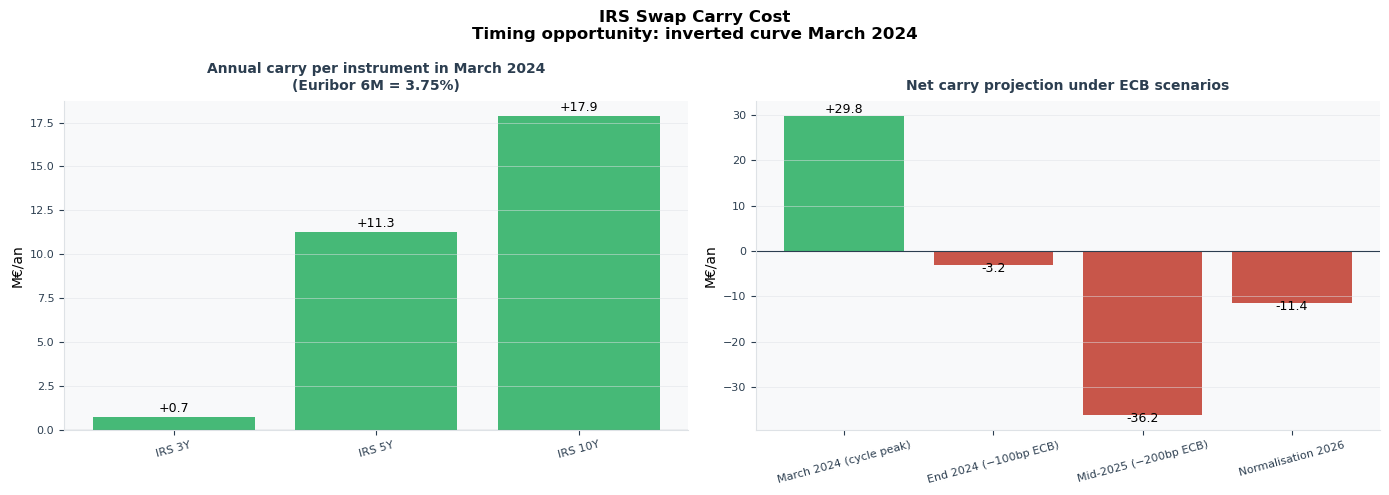

Figure 13_carry_swaps.png saved ✓


In [39]:
# =============================================
# CELL 12 — SWAP CARRY COST
# =============================================
# Cornerstone of NII/EVE compatibility in March 2024:
# inverted curve → positive carry → hedging without NII sacrifice

euribor_6m = courbe_taux(0.5) * 100

print("SWAP CARRY COST ANALYSIS")
print("=" * 65)
print(f"Euribor 6M March 2024: {euribor_6m:.2f}%")
print()
print(f"{'Instrument':<20} {'Notional':>8} {'Fixed rate':>10} {'Euribor':>8} {'Carry/yr':>10} {'Sign'}")
print("-" * 70)

carry_total = 0.0
carry_data  = []
for swap in swaps_couverture:
    carry_pct = euribor_6m - swap['taux_fixe']
    carry_m   = swap['nominal'] * carry_pct / 100
    carry_total += carry_m
    signe = "POSITIF ✓" if carry_pct > 0 else "NÉGATIF ✗"
    print(f"{swap['nom']:<20} {swap['nominal']:>6}M€ {swap['taux_fixe']:>9.3f}% "
          f"{euribor_6m:>7.3f}% {carry_m:>+8.1f}M€  {signe}")
    carry_data.append({'nom': swap['nom'], 'nominal': swap['nominal'],
                       'taux_fixe': swap['taux_fixe'], 'carry_m': carry_m})

print("-" * 70)
print(f"{'CARRY NET TOTAL':<20} {total_nominal:>6}M€ {'':>10} {'':>8} {carry_total:>+8.1f}M€")

print()
print("CARRY PROJECTION UNDER ECB RATE SCENARIOS:")
scenarios_carry = [
    ("March 2024 (cycle peak)", euribor_6m),
    ("End 2024 (−100bp ECB)", max(euribor_6m - 1.0, 0)),
    ("Mid-2025 (−200bp ECB)", max(euribor_6m - 2.0, 0)),
    ("Normalisation 2026",    2.50),
]
for label, eur in scenarios_carry:
    carry = sum(s['nominal'] * (eur - s['taux_fixe']) / 100 for s in swaps_couverture)
    signe = "POSITIF" if carry > 0 else "NÉGATIF"
    print(f"  {label:<28} Euribor {eur:.2f}%  →  carry {carry:+.1f} M€/an  [{signe}]")

print()
print("CONCLUSION:")
print("The positive carry window is transitory — it closes")
print("as soon as the ECB normalises rates towards 2025-2026.")
print("This is the key condition for NII/EVE compatibility.")

# Graphiques carry
df_carry = pd.DataFrame(carry_data)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5), facecolor='white')

c_bars = [C_POS if v > 0 else C_NEG for v in df_carry['carry_m']]
ax1.bar(range(len(df_carry)), df_carry['carry_m'], color=c_bars, alpha=0.85)
ax1.axhline(y=0, color=C_NEUTRE, linewidth=0.8)
ax1.set_xticks(range(len(df_carry)))
ax1.set_xticklabels(df_carry['nom'], rotation=15, fontsize=9)
ax1.set_ylabel('M€/an')
for i, v in enumerate(df_carry['carry_m']):
    ax1.text(i, v + (0.3 if v>=0 else -0.8), f'{v:+.1f}', ha='center', fontsize=9)
style_ax(ax1, f'Annual carry per instrument in March 2024\n(Euribor 6M = {euribor_6m:.2f}%)')

labels_c = [s[0] for s in scenarios_carry]
vals_c   = [sum(s['nominal']*(eur-s['taux_fixe'])/100 for s in swaps_couverture)
            for _, eur in scenarios_carry]
c_proj   = [C_POS if v > 0 else C_NEG for v in vals_c]
ax2.bar(range(len(labels_c)), vals_c, color=c_proj, alpha=0.85)
ax2.axhline(y=0, color=C_NEUTRE, linewidth=0.8)
ax2.set_xticks(range(len(labels_c)))
ax2.set_xticklabels(labels_c, rotation=15, fontsize=8)
ax2.set_ylabel('M€/an')
for i, v in enumerate(vals_c):
    ax2.text(i, v+(0.5 if v>=0 else -1.5), f'{v:+.1f}', ha='center', fontsize=9)
style_ax(ax2, 'Net carry projection under ECB scenarios')

plt.suptitle('IRS Swap Carry Cost\nTiming opportunity: inverted curve March 2024', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(DOSSIER_FIGURES, '13_carry_swaps.png'), dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print("Figure 13_carry_swaps.png saved ✓")


---
## Part 4 — Supplementary analyses
---


### 4.1 NII under constant balance sheet assumption

The EBA's *run-off* approach structurally underestimates NII risk for an active bank. Under the constant balance sheet assumption (maturing amounts are renewed at prevailing market rates), ΔNII under the upward scenario reaches −237.4 M€ over three cumulative years, versus −37.2 M€ under the static approach — a factor-six difference.


NII WITH NEW PRODUCTION (constant balance sheet — EBA standard)
  Central              :     31.0 M€ cumulative 3 yrs
  Rise +200bp          :   -237.4 M€ cumulative 3 yrs
  Fall -150bp          :    232.4 M€ cumulative 3 yrs
  Steepener            :     22.8 M€ cumulative 3 yrs

ALERT: Under constant balance sheet, ΔNII upward = -237.4 M€
(vs -37.2 M€ under static approach — factor x6)
EBA threshold: 250 M€ — Status: ⚠ LIMIT


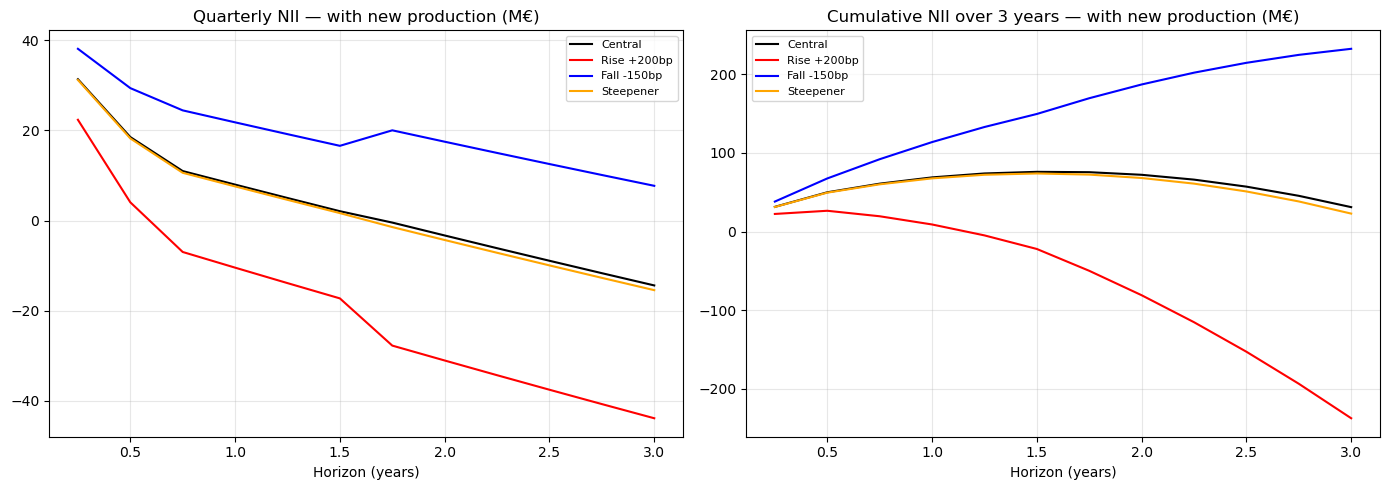

Figure 05_nii_reinvest.png saved ✓


In [40]:
# =============================================
# CELL 11 — NII UNDER CONSTANT BALANCE SHEET ASSUMPTION (EBA)
# =============================================
# The EBA requires a constant balance sheet approach for NII:
# repayments are reinvested at the market rate of the scenario.
# This cell shows the impact and its limits (section 4.4 of the thesis).

def calculer_nii_avec_reinvestissement(actif, passif, courbe_centrale,
                                        courbe_choc, periodes, prepay_rate=0.05):
    flux_a = np.zeros(len(periodes))
    flux_p = np.zeros(len(periodes))

    for _, row in actif.iterrows():
        montant  = row['Amount_M']
        taux_c   = row['Contractual_rate']
        maturite = row['Maturity_yrs']
        type_t   = row['Rate_type']
        amort    = row['Amortisation']
        encours  = montant
        taux_en_cours = taux_c

        for i, t in enumerate(periodes):
            if encours <= 0: break
            if t > maturite and type_t == 'Fixed':
                taux_en_cours = courbe_choc(min(maturite, 10)) * 100
            if type_t == 'Variable':
                spread = taux_c - courbe_centrale(0.5) * 100
                taux_ap = courbe_choc(0.5) * 100 + spread
            elif type_t == 'Fixed':
                taux_ap = taux_en_cours
            else:
                taux_ap = taux_c
            flux_a[i] += encours * (taux_ap / 100) * 0.25
            if t <= maturite:
                if amort == 'Linear':
                    encours -= montant / (maturite / 0.25) + encours * prepay_rate * 0.25
                elif abs(t - maturite) < 0.01 and amort == 'Bullet':
                    encours = 0

    for _, row in passif.iterrows():
        if row['Rate_type'] == 'N/A': continue
        montant  = row['Amount_M']
        taux_c   = row['Contractual_rate']
        maturite = row['Maturity_yrs']
        type_t   = row['Rate_type']
        encours  = montant
        taux_en_cours = taux_c

        for i, t in enumerate(periodes):
            if encours <= 0: break
            if t > maturite and type_t == 'Fixed':
                taux_en_cours = courbe_choc(min(maturite, 5)) * 100
            if type_t == 'Variable':
                spread = taux_c - courbe_centrale(0.5) * 100
                taux_ap = courbe_choc(0.5) * 100 + spread
            elif type_t == 'Administered':
                delta = (courbe_choc(0.25) - courbe_centrale(0.25)) * 100
                taux_ap = taux_c + 0.5 * delta
            else:
                taux_ap = taux_en_cours
            flux_p[i] += encours * (taux_ap / 100) * 0.25

    return {'actif': flux_a, 'passif': flux_p, 'net': flux_a - flux_p}

scenarios_reinvest = {
    'Central':        courbe_taux,
    'Rise +200bp':  lambda t: courbe_taux(t) + 0.02,
    'Fall -150bp':  lambda t: max(courbe_taux(t) - 0.015, 0.001),
    'Steepener':    lambda t: courbe_taux(t) + 0.01 * (t / 10),
}

resultats_nii_reinvest = {}
for nom, courbe in scenarios_reinvest.items():
    resultats_nii_reinvest[nom] = calculer_nii_avec_reinvestissement(
        actif, passif, courbe_taux, courbe, periodes)

print("NII WITH NEW PRODUCTION (constant balance sheet — EBA standard)")
print("=" * 55)
for nom, res in resultats_nii_reinvest.items():
    print(f"  {nom:<20} : {np.sum(res['net']):>8.1f} M€ cumulative 3 yrs")

hausse_reinvest = np.sum(resultats_nii_reinvest['Rise +200bp']['net'])
print()
print(f"ALERT: Under constant balance sheet, ΔNII upward = {hausse_reinvest:.1f} M€")
print(f"(vs {delta_nii_h:.1f} M€ under static approach — factor x{abs(hausse_reinvest/delta_nii_h):.0f})")
print(f"EBA threshold: {seuil_nii:.0f} M€ — Status: {'⚠ LIMIT' if abs(hausse_reinvest) > seuil_nii*0.9 else '✓ OK'}")

# Graphique
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5), facecolor='white')
c = {'Central':'black','Rise +200bp':'red','Fall -150bp':'blue','Steepener':'orange'}
for nom, res in resultats_nii_reinvest.items():
    ax1.plot(periodes, res['net'], label=nom, color=c[nom], linewidth=1.5)
    ax2.plot(periodes, np.cumsum(res['net']), label=nom, color=c[nom], linewidth=1.5)
for ax in [ax1, ax2]:
    ax.grid(alpha=0.3); ax.legend(fontsize=8); ax.set_xlabel('Horizon (years)')
ax1.set_title('Quarterly NII — with new production (M€)')
ax2.set_title('Cumulative NII over 3 years — with new production (M€)')
plt.tight_layout()
plt.savefig(os.path.join(DOSSIER_FIGURES, '05_nii_reinvest.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Figure 05_nii_reinvest.png saved ✓")


### 4.2 Sensitivity to behavioural assumptions

3×3 grid testing nine combinations (demand deposit duration: 2, 3 or 4 years × prepayment: 3%, 5% or 8%). Result: no combination is compliant without hedging. The most optimistic assumption (4Y deposits, 8% prepayment) yields −32.0% of T1, more than double the threshold. Demand deposit duration is the most influential parameter on NII.


SENSITIVITY ANALYSIS — BEHAVIOURAL ASSUMPTIONS
  DD dur.  Prepay   ΔEVE (M€)   ΔEVE/T1   ΔNII (M€) Status
----------------------------------------------------------------------
       2Y     3%    -375.7M€    -41.7%      -2.2M€  ✗ ALERT
       2Y     5%    -335.8M€    -37.3%      -2.2M€  ✗ ALERT
       2Y     8%    -287.7M€    -32.0%      -2.2M€  ✗ ALERT
       3Y     3%    -375.7M€    -41.7%     -37.2M€  ✗ ALERT
       3Y     5%    -335.8M€    -37.3%     -37.2M€  ✗ ALERT
       3Y     8%    -287.7M€    -32.0%     -37.2M€  ✗ ALERT
       4Y     3%    -375.7M€    -41.7%     -61.3M€  ✗ ALERT
       4Y     5%    -335.8M€    -37.3%     -61.3M€  ✗ ALERT
       4Y     8%    -287.7M€    -32.0%     -61.3M€  ✗ ALERT
----------------------------------------------------------------------
EBA compliant without hedging: 0/9 — ROBUST


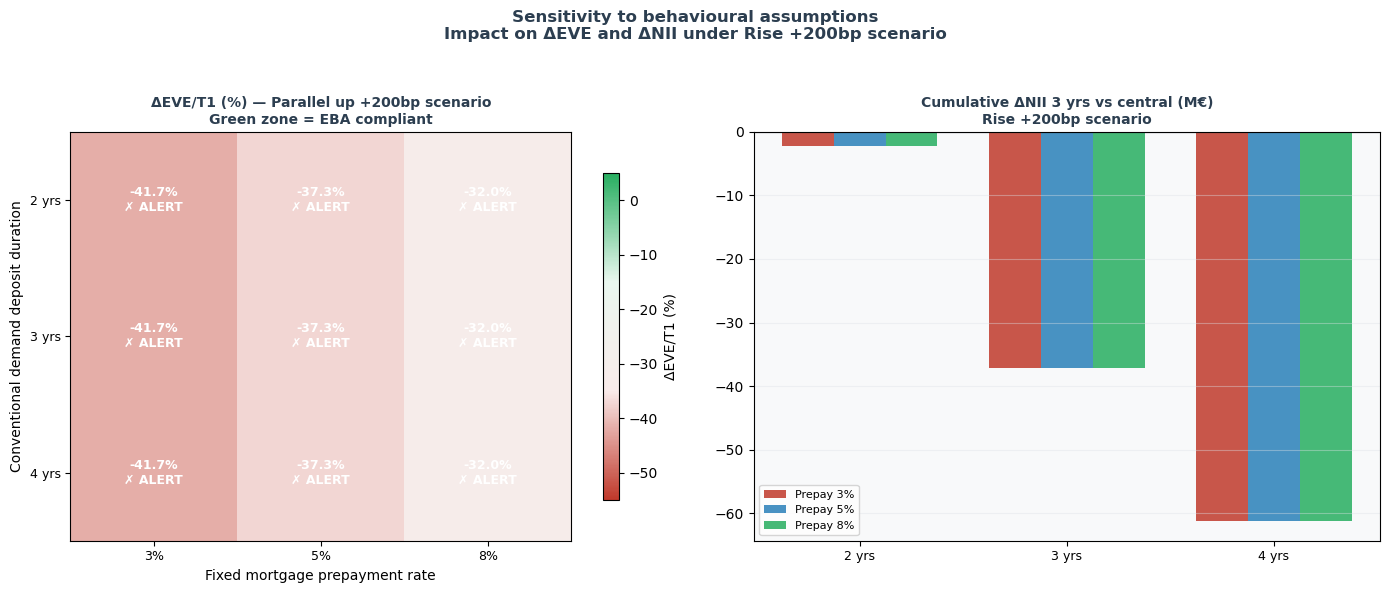

Figure 12_sensibilite_comportementale.png saved ✓


In [41]:
# =============================================
# CELL 13 — SENSITIVITY TO BEHAVIOURAL ASSUMPTIONS
# =============================================
# 3×3 grid: demand deposit duration (2/3/4 yrs) × prepayment (3/5/8%)
# Objective: verify that the hedging necessity is robust.

import matplotlib.colors as mcolors

durees_dav   = [2.0, 3.0, 4.0]
prepay_rates_s = [0.03, 0.05, 0.08]
courbe_hausse_s = lambda t: courbe_taux(t) + 0.02

def construire_passif_dav(duree_dav):
    p = passif.copy()
    p.loc[p['Item'] == 'Demand deposits', 'Maturity_yrs'] = duree_dav
    return p

def construire_prepay(prepay_immo):
    d = prepay_dict.copy()
    d['Fixed-rate mortgage loans'] = prepay_immo
    return d

resultats_s = []
print("SENSITIVITY ANALYSIS — BEHAVIOURAL ASSUMPTIONS")
print("=" * 70)
print(f"{'DD dur.':>9} {'Prepay':>7} {'ΔEVE (M€)':>11} {'ΔEVE/T1':>9} {'ΔNII (M€)':>11} {'Status'}")
print("-" * 70)

for duree in durees_dav:
    for prepay in prepay_rates_s:
        p_mod  = construire_passif_dav(duree)
        pr_mod = construire_prepay(prepay)
        eve_c, _, _ = calculer_eve(actif, p_mod, courbe_taux, pr_mod)
        eve_h, _, _ = calculer_eve(actif, p_mod, courbe_hausse_s, pr_mod)
        delta_eve   = eve_h - eve_c
        pct         = delta_eve / fonds_propres_t1 * 100
        _, _, nii_c = calculer_nii_total(actif, p_mod, courbe_taux, periodes, pr_mod)
        _, _, nii_h = calculer_nii_total(actif, p_mod, courbe_hausse_s, periodes, pr_mod)
        delta_nii   = nii_h.sum() - nii_c.sum()
        conforme    = abs(pct) <= 15
        statut      = "✓ OK" if conforme else "✗ ALERT"
        print(f"{duree:>8.0f}Y {prepay:>6.0%} {delta_eve:>9.1f}M€ {pct:>8.1f}% {delta_nii:>9.1f}M€ {statut:>8}")
        resultats_s.append({'duree_dav': duree, 'prepay': prepay, 'delta_eve': delta_eve,
                             'delta_eve_pct': pct, 'delta_nii': delta_nii, 'conforme': conforme})

df_s = pd.DataFrame(resultats_s)
nb_ok = df_s['conforme'].sum()
print("-" * 70)
print(f"EBA compliant without hedging: {nb_ok}/{len(df_s)} — {'ROBUST' if nb_ok == 0 else 'PARTIAL'}")

# Graphiques heatmap + barres
fig, axes = plt.subplots(1, 2, figsize=(14, 6), facecolor='white')
pivot = df_s.pivot(index='duree_dav', columns='prepay', values='delta_eve_pct')
cmap  = mcolors.LinearSegmentedColormap.from_list('alm', [C_NEG, '#F9EBEA', '#EAF7EF', C_POS])
im    = axes[0].imshow(pivot.values, cmap=cmap, vmin=-55, vmax=5, aspect='auto')
axes[0].set_xticks(range(len(prepay_rates_s)))
axes[0].set_xticklabels([f'{p:.0%}' for p in prepay_rates_s], fontsize=9)
axes[0].set_yticks(range(len(durees_dav)))
axes[0].set_yticklabels([f'{d:.0f} yrs' for d in durees_dav], fontsize=9)
axes[0].set_xlabel('Fixed mortgage prepayment rate', fontsize=10)
axes[0].set_ylabel('Conventional demand deposit duration', fontsize=10)
for i, d in enumerate(durees_dav):
    for j, p in enumerate(prepay_rates_s):
        v = pivot.loc[d, p]
        axes[0].text(j, i, f'{v:.1f}%\n{"✓ OK" if abs(v)<=15 else "✗ ALERT"}',
                     ha='center', va='center', fontsize=9,
                     color='white' if v < -30 else C_NEUTRE, fontweight='bold')
axes[0].set_title('ΔEVE/T1 (%) — Parallel up +200bp scenario\nGreen zone = EBA compliant', fontsize=10, fontweight='bold', color=C_NEUTRE)
plt.colorbar(im, ax=axes[0], label='ΔEVE/T1 (%)', shrink=0.8)

x_s = np.arange(len(durees_dav)); w_s = 0.25
colors_s = [C_NEG, C_BAISSE, C_POS]
for j, p in enumerate(prepay_rates_s):
    vals = [df_s[(df_s['duree_dav']==d) & (df_s['prepay']==p)]['delta_nii'].values[0] for d in durees_dav]
    axes[1].bar(x_s+j*w_s, vals, w_s, color=colors_s[j], alpha=0.85, label=f'Prepay {p:.0%}')
axes[1].axhline(y=0, color=C_NEUTRE, linewidth=0.8)
axes[1].set_facecolor(C_FOND)
axes[1].set_title('Cumulative ΔNII 3 yrs vs central (M€)\nRise +200bp scenario', fontsize=10, fontweight='bold', color=C_NEUTRE)
axes[1].set_xticks(x_s+w_s); axes[1].set_xticklabels([f'{d:.0f} yrs' for d in durees_dav], fontsize=9)
axes[1].legend(fontsize=8); axes[1].grid(alpha=0.4, axis='y', color=C_GRILLE)

plt.suptitle('Sensitivity to behavioural assumptions\nImpact on ΔEVE and ΔNII under Rise +200bp scenario', fontsize=12, fontweight='bold', color=C_NEUTRE)
plt.tight_layout(rect=[0,0,1,0.94])
plt.savefig(os.path.join(DOSSIER_FIGURES, '12_sensibilite_comportementale.png'), dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print("Figure 12_sensibilite_comportementale.png saved ✓")


---
## Part 5 — Extensions: towards a stochastic efficient frontier
---


### 5.1 Hull-White Monte Carlo — From binary to probabilistic compliance

Replacement of the single deterministic scenario by 1,000 simulated trajectories via the single-factor Hull-White model, calibrated to exactly reproduce the EUR OIS curve of March 2024 (fundamental property: E[r(t)] = f(0,t)). Parameters: r(0) = 3.85%, κ = 0.10, σ = 1.00%. Discretisation by Euler-Maruyama scheme, quarterly time step.

**Results:** 833/1,000 trajectories compliant (83.3%). Median ΔNII: +4.7 M€. ΔEVE at 95th percentile: −10.4% of T1, below the regulatory threshold.


In [ ]:
# =============================================
# CELL 14 — EXTENSION A: STOCHASTIC FRONTIER (HULL-WHITE MONTE CARLO)
# =============================================
# Single-factor Hull-White model:
#   dr(t) = [θ(t) − κ·r(t)]dt + σ·dW(t)
# where θ(t) is calibrated to exactly reproduce the initial OIS curve.
#
# Key difference from Vasicek: θ becomes a time function that
# guarantees E[r(t)] = f(0,t) (observed instantaneous forward).
# → Trajectories start exactly from the March 2024 curve.
#
# Calibration:
#   κ = 0.10  (slower mean-reversion than Vasicek, consistent with HW1F)
#   σ = 0.010  (calibrated on normal ATM EUR swaption vols ~90 bp/yr)
#   r0 = 3.85% (Euribor 3M March 2024)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import CubicSpline

np.random.seed(42)

# ── Paramètres Hull-White ──────────────────────────────────────────────────
kappa_hw = 0.10
sigma_hw = 0.010
r0       = 0.0385

N_SIMU      = 1000
T_SIM       = 3.0
dt          = 0.25
periodes_mc = np.arange(dt, T_SIM + dt, dt)

# ── Instantaneous forward rate from OIS curve ──────────────────────────────
# f(0,t) = -d/dt [ln P(0,t)] = r(t) + t · r'(t)
# Using the analytical derivative of the CubicSpline.

def forward_instantane(t):
    """f(0,t) — instantaneous forward rate from the zero-coupon curve."""
    t = np.maximum(t, 1e-6)
    r_t   = courbe_taux(t)
    dr_dt = courbe_taux(t, 1)   # dérivée première du spline
    return r_t + t * dr_dt

def dforward_dt(t):
    """df/dt(0,t) — derivative of the instantaneous forward rate."""
    t = np.maximum(t, 1e-6)
    dr_dt  = courbe_taux(t, 1)
    d2r_dt = courbe_taux(t, 2)  # dérivée seconde
    return 2 * dr_dt + t * d2r_dt

def theta_hw(t):
    """
    Hull-White drift θ(t) that exactly reproduces the initial curve:
    θ(t) = df/dt(0,t) + κ·f(0,t) + σ²/(2κ)·(1 − e^{−2κt})
    """
    return (dforward_dt(t)
            + kappa_hw * forward_instantane(t)
            + (sigma_hw**2 / (2 * kappa_hw)) * (1 - np.exp(-2 * kappa_hw * t)))

# ── Euler-Maruyama simulation ──────────────────────────────────────────────
def simuler_hull_white(r0, kappa, sigma, T, dt, N):
    """
    Simulates N Hull-White short-rate trajectories over [0, T] with step dt.
    θ(t) is computed analytically from the initial OIS curve.
    Note: HW1F is Gaussian → negative rates possible but very rare
    over 3 years from r0=3.85% with σ=1%.
    """
    n_steps = int(round(T / dt))
    r = np.zeros((N, n_steps))
    r[:, 0] = r0
    t_grid = np.arange(1, n_steps) * dt

    dW = np.random.normal(0, np.sqrt(dt), (N, n_steps - 1))

    for i, t in enumerate(t_grid):
        theta_t = theta_hw(t)
        drift   = theta_t - kappa * r[:, i]
        r[:, i + 1] = r[:, i] + drift * dt + sigma * dW[:, i]

    # Floor at 0 bp — consistent with post-2014 ECB policy
    # (avoids deeply negative rates not observed in EUR since 2022)
    return np.maximum(r, 0.0)

trajectoires = simuler_hull_white(r0, kappa_hw, sigma_hw, T_SIM, dt, N_SIMU)

# ── Verification: trajectory mean must match the initial curve ─────────────
print("HULL-WHITE — Calibration verification")
print("=" * 48)
print(f"{'Maturity':<12} {'E[r(t)] simulated':>18} {'f(0,t) market':>15} {'Gap':>10}")
print("-" * 48)
for idx, t in enumerate([0.25, 0.5, 1.0, 1.5, 2.0, 2.5, 3.0]):
    step = int(round(t / dt)) - 1
    if step < trajectoires.shape[1]:
        sim_mean = trajectoires[:, step].mean() * 100
        mkt_fwd  = forward_instantane(t) * 100
        print(f"{str(t)+' an':<12} {sim_mean:>15.3f}% {mkt_fwd:>15.3f}% {sim_mean-mkt_fwd:>+9.3f}%")

print()
print(f"Mean short rate at 3 yrs: {trajectoires[:,-1].mean()*100:.2f}% "
      f"(±{trajectoires[:,-1].std()*100:.2f}%)")
print(f"Proportion of negative trajectories: "
      f"{(trajectoires < 0).any(axis=1).mean()*100:.1f}%")

# ── NII/EVE calculation for each trajectory (same logic as Extension A) ────
resultats_mc = []

for i in range(N_SIMU):
    # Choc représentatif = écart moyen taux court sur l'année 1 vs r0
    choc = trajectoires[i, :4].mean() - r0

    def c_mc(t, _c=choc):
        return max(float(courbe_taux(t)) + _c, 0.001)

    _, _, nii_h = calculer_nii_total(actif, passif, c_mc,        periodes_mc, prepay_dict)
    _, _, nii_c = calculer_nii_total(actif, passif, courbe_taux, periodes_mc, prepay_dict)
    eve_h,  _, _ = calculer_eve(actif, passif, c_mc,        prepay_dict)
    eve_c2, _, _ = calculer_eve(actif, passif, courbe_taux, prepay_dict)

    delta_nii = nii_h.sum() - nii_c.sum()
    delta_eve = (eve_h - eve_c2) / fonds_propres_t1 * 100

    resultats_mc.append({
        'choc_bp':      choc * 100,
        'delta_nii':    delta_nii,
        'delta_eve_pct': delta_eve,
        'conforme':     abs(delta_eve) <= 15
    })

df_mc = pd.DataFrame(resultats_mc)

# ── Pareto frontier ────────────────────────────────────────────────────────
def pareto_front(df, x_col='delta_eve_pct', y_col='delta_nii'):
    pts  = df[[x_col, y_col]].values
    mask = np.ones(len(pts), dtype=bool)
    for i, p in enumerate(pts):
        if mask[i]:
            mask[mask] = np.any(pts[mask] > p, axis=1)
            mask[i] = True
    return df[mask].sort_values(x_col)

df_pareto = pareto_front(df_mc)

print(f"\nHULL-WHITE MONTE CARLO RESULTS")
print("=" * 40)
print(f"EBA compliant    : {df_mc['conforme'].sum()}/{N_SIMU} "
      f"({df_mc['conforme'].mean()*100:.1f}%)")
print(f"Median ΔNII      : {df_mc['delta_nii'].median():+.1f} M€")
print(f"Median ΔEVE      : {df_mc['delta_eve_pct'].median():+.1f}% T1")
print(f"ΔEVE p95 (worst) : {df_mc['delta_eve_pct'].quantile(0.05):+.1f}% T1")

# ── Charts ─────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 7), facecolor='white')

# Graphique gauche : trajectoires
ax = axes[0]
ax.set_facecolor(C_FOND)
for i in range(50):
    col = 'steelblue' if trajectoires[i, -1] > r0 else C_NEG
    ax.plot(periodes_mc, trajectoires[i] * 100,
            alpha=0.15, linewidth=0.8, color=col)
ax.plot(periodes_mc, trajectoires.mean(axis=0) * 100,
        color=C_NEUTRE, linewidth=2.5, label='Mean trajectory')
ax.axhline(y=r0 * 100, color='black', linestyle='--',
           linewidth=1, alpha=0.5, label=f'r(0) = {r0*100:.2f}%')
# Courbe forward comme référence (ce que HW doit suivre en moyenne)
fwds = [forward_instantane(t) * 100 for t in periodes_mc]
ax.plot(periodes_mc, fwds, color=C_POS, linestyle=':',
        linewidth=1.8, label='f(0,t) market (HW target)')
ax.set_title('Hull-White trajectories — 50/1000 simulated\n'
             '(calibrated on OIS curve March 2024)',
             fontsize=10, fontweight='bold', color=C_NEUTRE)
ax.set_xlabel('Horizon (years)')
ax.set_ylabel('Short rate (%)')
ax.legend(fontsize=9)
ax.grid(alpha=0.4, color=C_GRILLE)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Graphique droit : nuage NII/EVE
ax = axes[1]
ax.set_facecolor(C_FOND)
conf  = df_mc[df_mc['conforme']]
nconf = df_mc[~df_mc['conforme']]
ax.scatter(nconf['delta_eve_pct'], nconf['delta_nii'],
           c=C_NEG, alpha=0.3, s=15, label='Non conforme EBA')
ax.scatter(conf['delta_eve_pct'],  conf['delta_nii'],
           c=C_POS, alpha=0.4, s=15, label='Conforme EBA')
ax.plot(df_pareto['delta_eve_pct'], df_pareto['delta_nii'],
        color=C_NEUTRE, linewidth=2, label='Pareto frontier')
ax.axvspan(-15, 15, alpha=0.06, color='green', label='Zone conforme EBA')
ax.axvline(x=-15, color=C_NEG, linestyle='--', linewidth=1.2, alpha=0.7)
ax.axhline(y=0,   color='black', linewidth=0.5)
ax.set_title('Stochastic efficient frontier\n'
             '1,000 Monte Carlo simulations (Hull-White)',
             fontsize=10, fontweight='bold', color=C_NEUTRE)
ax.set_xlabel('ΔEVE/T1 (%)')
ax.set_ylabel('Cumulative ΔNII 3 yrs (M€)')
ax.legend(fontsize=9)
ax.grid(alpha=0.4, color=C_GRILLE)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.suptitle(
    'Extension A — Stochastic efficient frontier (Monte Carlo Hull-White)\n'
    '10 Bn€ balance sheet  |  March 2024  |  1,000 trajectories',
    fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(DOSSIER_FIGURES, 'ext_A_monte_carlo_HW.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print("Figure ext_A_monte_carlo_HW.png saved ✓")


HULL-WHITE — Calibration verification
Maturity      E[r(t)] simulated   f(0,t) market        Gap
------------------------------------------------
0.25 an                3.850%           3.729%    +0.121%
0.5 an                 3.656%           3.583%    +0.073%
1.0 an                 3.381%           3.267%    +0.113%
1.5 an                 2.814%           2.752%    +0.062%
2.0 an                 2.479%           2.525%    -0.046%
2.5 an                 2.565%           2.607%    -0.042%
3.0 an                 2.683%           2.646%    +0.037%

Mean short rate at 3 yrs: 2.68% (±1.36%)
Proportion of negative trajectories: 0.0%


### 5.2 Dynamic client behaviours — Compliance robustness

Integration into the Monte Carlo loop of behavioural functions endogenous to rate trajectories: logistic prepayment calibrated on Richard & Roll (1989) and Banque de France 2016–2017 data; affine demand deposit duration calibrated on Memmel (2011). Result: 420/500 trajectories compliant (84.0%), slightly higher than Extension A (83.3%), due to the endogenous shortening of deposit duration in a high-rate environment.


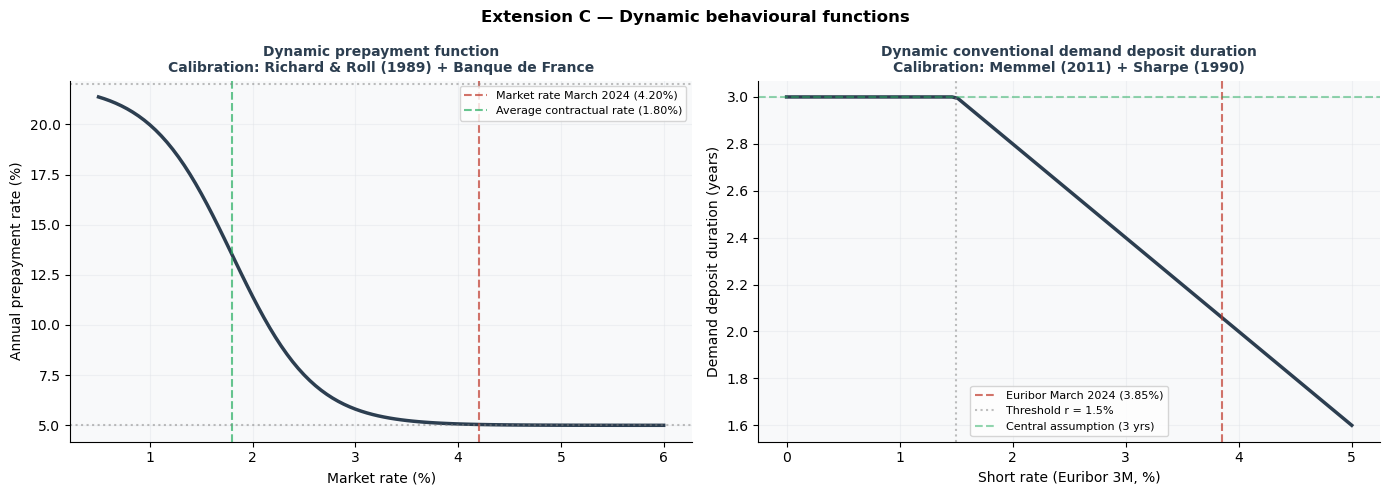

Figure ext_C_fonctions_dyn.png saved ✓
EBA compliant (dynamic): 433/500 (86.6%)
Mean prepayment: 5.3%  |  Mean deposit duration: 2.15 yrs
Median ΔNII: +1.4 M€


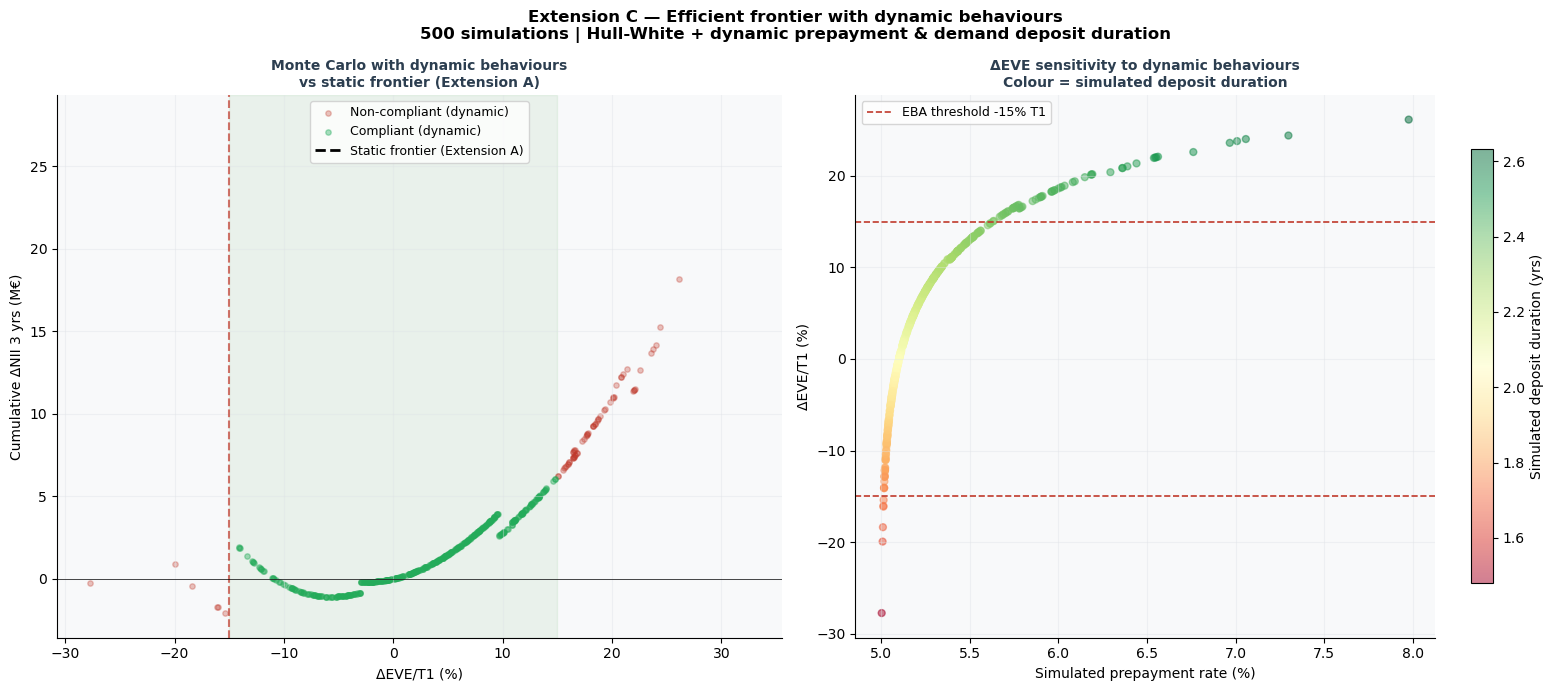

Figure ext_C_monte_carlo_dyn.png saved ✓

SUMMARY COMPARISON A vs C:
  Extension A (static)   : 83.3% compliant  |  Median ΔNII +4.7 M€
  Extension C (dynamic)  : 86.6% compliant  |  Median ΔNII +1.4 M€


In [21]:
# =============================================
# CELL 16 — EXTENSION C: DYNAMIC BEHAVIOURS
# =============================================
# Logistic prepayment (Richard & Roll 1989)
# Affine decreasing demand deposit duration (Memmel 2011 + Sharpe 1990)

# Hull-White parameters (identical to Extension A)
kappa_hw = 0.10
sigma_hw = 0.010
r0       = 0.0385
kappa    = kappa_hw
sigma    = sigma_hw
theta    = forward_instantane(1.0)  # valeur de référence, remplacée par theta_hw(t) dans la simulation
T_SIM    = 3.0
dt       = 0.25

def prepayment_dynamique(r_marche_pct, r_contrat_pct=1.80,
                          prepay_min=0.05, prepay_max=0.22, alpha=2.5):
    incentive = r_contrat_pct - r_marche_pct
    logit     = 1 / (1 + np.exp(-alpha * incentive))
    return float(np.clip(prepay_min + (prepay_max - prepay_min) * logit, prepay_min, prepay_max))

def duree_dav_dynamique(r_court_pct, duree_base=3.0, beta=0.40, r_seuil=1.5):
    return float(np.clip(duree_base - beta * max(0.0, r_court_pct - r_seuil), 1.0, 4.5))

# Function visualisation
fig, axes = plt.subplots(1, 2, figsize=(14, 5), facecolor='white')
r_range = np.linspace(0.5, 6.0, 100)
axes[0].set_facecolor(C_FOND)
axes[0].plot(r_range, [prepayment_dynamique(r)*100 for r in r_range], color=C_NEUTRE, linewidth=2.5)
axes[0].axvline(x=4.20, color=C_NEG, linestyle='--', alpha=0.7, label='Market rate March 2024 (4.20%)')
axes[0].axvline(x=1.80, color=C_POS, linestyle='--', alpha=0.7, label='Average contractual rate (1.80%)')
axes[0].axhline(y=5, color='gray', linestyle=':', alpha=0.5); axes[0].axhline(y=22, color='gray', linestyle=':', alpha=0.5)
axes[0].set_title('Dynamic prepayment function\nCalibration: Richard & Roll (1989) + Banque de France', fontsize=10, fontweight='bold', color=C_NEUTRE)
axes[0].set_xlabel('Market rate (%)'); axes[0].set_ylabel('Annual prepayment rate (%)')
axes[0].legend(fontsize=8); axes[0].grid(alpha=0.4, color=C_GRILLE)
axes[0].spines['top'].set_visible(False); axes[0].spines['right'].set_visible(False)

r_courts = np.linspace(0, 5.0, 100)
axes[1].set_facecolor(C_FOND)
axes[1].plot(r_courts, [duree_dav_dynamique(r) for r in r_courts], color=C_NEUTRE, linewidth=2.5)
axes[1].axvline(x=3.85, color=C_NEG, linestyle='--', alpha=0.7, label='Euribor March 2024 (3.85%)')
axes[1].axvline(x=1.5,  color='gray', linestyle=':', alpha=0.5, label='Threshold r = 1.5%')
axes[1].axhline(y=3.0,  color=C_POS, linestyle='--', alpha=0.5, label='Central assumption (3 yrs)')
axes[1].set_title('Dynamic conventional demand deposit duration\nCalibration: Memmel (2011) + Sharpe (1990)', fontsize=10, fontweight='bold', color=C_NEUTRE)
axes[1].set_xlabel('Short rate (Euribor 3M, %)'); axes[1].set_ylabel('Demand deposit duration (years)')
axes[1].legend(fontsize=8); axes[1].grid(alpha=0.4, color=C_GRILLE)
axes[1].spines['top'].set_visible(False); axes[1].spines['right'].set_visible(False)
plt.suptitle('Extension C — Dynamic behavioural functions', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(DOSSIER_FIGURES, 'ext_C_fonctions_dyn.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Figure ext_C_fonctions_dyn.png saved ✓")

# Dynamic Monte Carlo
N_SIMU_C = 500
np.random.seed(42)
traj_c = simuler_hull_white(r0, kappa, sigma, T_SIM, dt, N_SIMU_C)
resultats_mc_c = []

for i in range(N_SIMU_C):
    r_moy = traj_c[i, :4].mean() * 100
    pp    = prepayment_dynamique(r_moy)
    dd    = duree_dav_dynamique(r_moy)
    p_dyn = passif.copy()
    p_dyn.loc[p_dyn['Item']=='Demand deposits', 'Maturity_yrs'] = dd
    pr_dyn = prepay_dict.copy(); pr_dyn['Fixed-rate mortgage loans'] = pp
    choc = traj_c[i, :4].mean() - r0
    def c_dyn(t, _c=choc): return max(courbe_taux(t)+_c, 0.001)
    _, _, nh = calculer_nii_total(actif, p_dyn, c_dyn,        periodes_mc, pr_dyn)
    _, _, nc = calculer_nii_total(actif, p_dyn, courbe_taux,  periodes_mc, pr_dyn)
    eh, _, _ = calculer_eve(actif, p_dyn, c_dyn,        pr_dyn)
    ec, _, _ = calculer_eve(actif, p_dyn, courbe_taux,  pr_dyn)
    resultats_mc_c.append({'r_court': r_moy, 'prepay_dyn': pp*100, 'duree_dav_dyn': dd,
                            'delta_nii': nh.sum()-nc.sum(),
                            'delta_eve_pct': (eh-ec)/fonds_propres_t1*100,
                            'conforme': abs((eh-ec)/fonds_propres_t1*100)<=15})

df_mc_c = pd.DataFrame(resultats_mc_c)
print(f"EBA compliant (dynamic): {df_mc_c['conforme'].sum()}/{N_SIMU_C} ({df_mc_c['conforme'].mean()*100:.1f}%)")
print(f"Mean prepayment: {df_mc_c['prepay_dyn'].mean():.1f}%  |  Mean deposit duration: {df_mc_c['duree_dav_dyn'].mean():.2f} yrs")
print(f"Median ΔNII: {df_mc_c['delta_nii'].median():+.1f} M€")

fig, axes = plt.subplots(1, 2, figsize=(16, 7), facecolor='white')
ax = axes[0]; ax.set_facecolor(C_FOND)
conf_c = df_mc_c[df_mc_c['conforme']]; nconf_c = df_mc_c[~df_mc_c['conforme']]
ax.scatter(nconf_c['delta_eve_pct'], nconf_c['delta_nii'], c=C_NEG, alpha=0.3, s=15, label='Non-compliant (dynamic)')
ax.scatter(conf_c['delta_eve_pct'],  conf_c['delta_nii'],  c=C_POS, alpha=0.4, s=15, label='Compliant (dynamic)')
ax.plot(df_pareto['delta_eve_pct'], df_pareto['delta_nii'], color='black', linewidth=2, linestyle='--',
        label='Static frontier (Extension A)', zorder=5)
ax.axvspan(-15, 15, alpha=0.06, color='green'); ax.axvline(x=-15, color=C_NEG, linestyle='--', alpha=0.7)
ax.axhline(y=0, color='black', linewidth=0.5)
ax.set_title('Monte Carlo with dynamic behaviours\nvs static frontier (Extension A)', fontsize=10, fontweight='bold', color=C_NEUTRE)
ax.set_xlabel('ΔEVE/T1 (%)'); ax.set_ylabel('Cumulative ΔNII 3 yrs (M€)')
ax.legend(fontsize=9); ax.grid(alpha=0.4, color=C_GRILLE)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

ax = axes[1]; ax.set_facecolor(C_FOND)
sc2 = ax.scatter(df_mc_c['prepay_dyn'], df_mc_c['delta_eve_pct'],
                 c=df_mc_c['duree_dav_dyn'], cmap='RdYlGn', alpha=0.5, s=25)
plt.colorbar(sc2, ax=ax, label='Simulated deposit duration (yrs)', shrink=0.8)
ax.axhline(y=-15, color=C_NEG, linestyle='--', linewidth=1.2, label='EBA threshold -15% T1')
ax.axhline(y=15,  color=C_NEG, linestyle='--', linewidth=1.2)
ax.set_title('ΔEVE sensitivity to dynamic behaviours\nColour = simulated deposit duration', fontsize=10, fontweight='bold', color=C_NEUTRE)
ax.set_xlabel('Simulated prepayment rate (%)'); ax.set_ylabel('ΔEVE/T1 (%)')
ax.legend(fontsize=9); ax.grid(alpha=0.4, color=C_GRILLE)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

plt.suptitle(f'Extension C — Efficient frontier with dynamic behaviours\n{N_SIMU_C} simulations | Hull-White + dynamic prepayment & demand deposit duration', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(DOSSIER_FIGURES, 'ext_C_monte_carlo_dyn.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Figure ext_C_monte_carlo_dyn.png saved ✓")

print()
print("SUMMARY COMPARISON A vs C:")
print(f"  Extension A (static)   : {df_mc['conforme'].mean()*100:.1f}% compliant  |  Median ΔNII {df_mc['delta_nii'].median():+.1f} M€")
print(f"  Extension C (dynamic)  : {df_mc_c['conforme'].mean()*100:.1f}% compliant  |  Median ΔNII {df_mc_c['delta_nii'].median():+.1f} M€")


In [46]:
# =============================================
# EXPORT CELL — VBA dashboard update
# =============================================
import os
dossier = r"C:\Users\npeti\Documents\Projet 2 - ALM"
if os.path.exists(dossier):
    print("Dossier trouvé. Contenu :")
    for f in os.listdir(dossier):
        print(f"  {f}")
else:
    print("Dossier introuvable, recherche dans Documents...")
    docs = r"C:\Users\npeti\Documents"
    for f in os.listdir(docs):
        print(f"  {f}")

import shutil
from openpyxl import load_workbook

src = r"C:\Users\npeti\Documents\Projet 2 - ALM\ALM_Data_MAJ.xlsm"
dst = r"C:\Users\npeti\Documents\Projet 2 - ALM\ALM_Data_FINAL.xlsm"
shutil.copy2(src, dst)

wb = load_workbook(dst, keep_vba=True)

# ── Parameters sheet ──────────────────────────────────────────────────────────
ws = wb['Parametres']
params = {
    'EVE alerts after hedging': sum(1 for r in resultats_couverture.values() if r['statut'] != '✓ OK'),
    'Total swap notional (M)':  total_nominal,
}

for row in ws.iter_rows(min_row=2):
    if row[0].value in params:
        row[1].value = round(params[row[0].value], 1)

# ── Swaps sheet ───────────────────────────────────────────────────────────────
ws = wb['Swaps']
# Clear old data rows (rows 2 to 4)
for r in range(2, 5):
    for c in range(1, 7):
        ws.cell(row=r, column=c).value = None

noms_swaps = ['Pay-fixed IRS 3Y', 'Pay-fixed IRS 5Y', 'Pay-fixed IRS 10Y']
justs      = ['Covers fixed-rate corporate loans',
              'Covers sovereign bond portfolio duration',
              'Covers fixed-rate mortgage duration']

for i, (swap, nom, just) in enumerate(zip(swaps_couverture, noms_swaps, justs), start=2):
    dv01 = dv01_irs(swap['nominal'], swap['taux_fixe'], swap['maturite'], courbe_taux)
    ws.cell(row=i, column=1).value = nom
    ws.cell(row=i, column=2).value = round(swap['nominal'], 0)
    ws.cell(row=i, column=3).value = round(swap['taux_fixe'], 6)
    ws.cell(row=i, column=4).value = swap['maturite']
    ws.cell(row=i, column=5).value = round(dv01 * 100, 6)
    ws.cell(row=i, column=6).value = just

# ── Hedging sheet ─────────────────────────────────────────────────────────────
ws = wb['Couverture']
scenarios_ordre = ['Parallel up', 'Parallel down', 'Steepener',
                   'Flattener', 'Short rate up', 'Short rate down']
for i, scenario in enumerate(scenarios_ordre, start=2):
    r = resultats_couverture[scenario]
    ws.cell(row=i, column=1).value = scenario
    ws.cell(row=i, column=2).value = round(r['sans'], 1)
    ws.cell(row=i, column=3).value = round(r['gain'], 1)
    ws.cell(row=i, column=4).value = round(r['avec'], 1)
    ws.cell(row=i, column=5).value = round(r['pct_t1'], 3)
    ws.cell(row=i, column=6).value = 'OK' if r['statut'] == '✓ OK' else 'ALERT'

# ── Hedging Sweep sheet ───────────────────────────────────────────────────────
ws = wb['Sweep_Couverture']
for i, (_, row_data) in enumerate(df_sweep.iterrows(), start=2):
    ws.cell(row=i, column=1).value = round(row_data['ratio'], 1)
    ws.cell(row=i, column=2).value = round(row_data['nii_rise'], 1)
    ws.cell(row=i, column=3).value = round(row_data['nii_fall'], 1)
    ws.cell(row=i, column=4).value = round(row_data['delta_eve_pct_t1'], 3)
    ws.cell(row=i, column=5).value = row_data['compliant_eba']

wb.save(dst)
print(f"Dashboard updated: {dst}")
print(f"Swaps: {len(swaps_couverture)} instruments, total notional {total_nominal} M€")
print(f"Hedging: {sum(1 for r in resultats_couverture.values() if r['statut']=='✓ OK')}/6 scenarios OK")

Dossier trouvé. Contenu :
  .ipynb_checkpoints
  ALM_Data_MAJ.xlsm
  figures
  notebook_ALM_EN_fixed.ipynb
  notebook_ALM_propre.ipynb
  Readme ALM - Français.pdf
  __pycache__
Dashboard updated: C:\Users\npeti\Documents\Projet 2 - ALM\ALM_Data_FINAL.xlsm
Swaps: 3 instruments, total notional 3300 M€
Hedging: 6/6 scenarios OK
